# Notebook 05 — Rainfall and Soil Factors

## Objective

This notebook prepares rainfall and soil-related flood-conditioning factors
for the Gomti River–influenced Lucknow study area.

The notebook uses externally sourced rainfall and soil datasets and converts
them into spatially consistent datasets suitable for subsequent flood
susceptibility modelling.

The main components are:

1. CHIRPS rainfall data
2. SoilGrids soil-property data

The processing workflow includes data acquisition, quality assessment,
study-area clipping, spatial verification, and preparation of final
conditioning-factor rasters.

The implemented temporal framework currently uses the LULC observation years:

- 2003
- 2014
- 2025

The rainfall and soil factor design will be finalized after evaluating
dataset availability, spatial resolution, temporal coverage, and scientific
suitability.

## 5.1 Notebook Setup

This step initializes the working environment for Notebook 05 and establishes
the project root directory.

Notebook 05 is developed independently from the previous notebooks, so the
required paths and environment variables are initialized explicitly rather
than relying on variables remaining in memory from Notebook 04.

The project root is used as the base directory for accessing raw datasets,
processed datasets, notebooks, and final outputs throughout the rainfall and
soil preprocessing workflow.

In [42]:
# ============================================================
# Step 05.1 — Notebook Setup
# ============================================================

from pathlib import Path

print("=" * 70)
print("NOTEBOOK 05 — RAINFALL AND SOIL FACTORS")
print("=" * 70)

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

NOTEBOOK 05 — RAINFALL AND SOIL FACTORS
Project root:
d:\Projects\GeoAI-Flood-Susceptibility


## 5.2 Project Directory Structure

This step defines the directory paths used throughout Notebook 05.

Raw rainfall data downloaded from CHIRPS are retained in the `data/raw`
directory and organized by observation year. Raw soil data are also stored
separately so that the original downloaded datasets remain unchanged.

Processed rainfall and soil datasets generated during this notebook are
stored under the Notebook 05 processing directory.

Final tables and figures are stored in the project's existing output
directories.

In [43]:
# ============================================================
# Step 05.2 — Define Project Directory Paths
# ============================================================

# ------------------------------------------------------------
# Raw data directories
# ------------------------------------------------------------

RAW_DIR = PROJECT_ROOT / "data" / "raw"

RAINFALL_RAW_DIR = (
    RAW_DIR / "rainfall"
)

SOIL_RAW_DIR = (
    RAW_DIR / "soil"
)

# ------------------------------------------------------------
# Processed data directory for Notebook 05
# ------------------------------------------------------------

PROCESSED_NB05_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
)

RAINFALL_PROCESSED_DIR = (
    PROCESSED_NB05_DIR / "rainfall"
)

SOIL_PROCESSED_DIR = (
    PROCESSED_NB05_DIR / "soil"
)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

OUTPUTS_DIR = (
    PROJECT_ROOT / "outputs"
)

TABLES_DIR = (
    OUTPUTS_DIR / "tables"
)

FIGURES_DIR = (
    OUTPUTS_DIR / "figures"
)

# ------------------------------------------------------------
# Display paths
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — PROJECT DIRECTORIES")
print("=" * 70)

print("\nRaw rainfall:")
print(RAINFALL_RAW_DIR)

print("\nRaw soil:")
print(SOIL_RAW_DIR)

print("\nProcessed rainfall:")
print(RAINFALL_PROCESSED_DIR)

print("\nProcessed soil:")
print(SOIL_PROCESSED_DIR)

print("\nTables:")
print(TABLES_DIR)

print("\nFigures:")
print(FIGURES_DIR)

NOTEBOOK 05 — PROJECT DIRECTORIES

Raw rainfall:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\rainfall

Raw soil:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\soil

Processed rainfall:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_05\rainfall

Processed soil:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_05\soil

Tables:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables

Figures:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures


## 5.3 Required Python Libraries

The rainfall and soil preprocessing workflow requires libraries for raster
processing, vector-data handling, numerical computation, tabular analysis,
and visualization.

The main libraries used in this notebook are:

- **Rasterio** — reading, writing, and processing raster datasets.
- **GeoPandas** — loading and handling the study-area vector geometry.
- **NumPy** — numerical and array-based calculations.
- **Pandas** — organizing rainfall and soil statistics in tabular form.
- **Matplotlib** — quality-control plots and final visualizations.

Only the libraries required for the current workflow are loaded.

In [44]:
# ============================================================
# Step 05.3 — Load Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

print("=" * 70)
print("NOTEBOOK 05 — LIBRARY CHECK")
print("=" * 70)

print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"GeoPandas   : {gpd.__version__}")
print(f"Rasterio    : {rasterio.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")

print("\n✓ All required libraries imported successfully.")

NOTEBOOK 05 — LIBRARY CHECK
NumPy       : 2.5.2
Pandas      : 3.0.5
GeoPandas   : 1.1.4
Rasterio    : 1.5.1
Matplotlib  : 3.11.1

✓ All required libraries imported successfully.


## 5.4 Load the Study-Area Boundary

The study area defined in Notebook 01 is reused in Notebook 05 to ensure
that rainfall and soil datasets are processed over exactly the same spatial
domain.

The study-area boundary is stored as a GeoPackage:

`data/processed/notebook_01/Lucknow_Search_Area_20km.gpkg`

The layer is loaded explicitly in this notebook and its CRS, geometry count,
and spatial extent are verified before being used for subsequent processing.

In [45]:
# ============================================================
# Step 05.4 — Load Study Area
# ============================================================

study_area_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)

# ------------------------------------------------------------
# Check that the file exists
# ------------------------------------------------------------

if not study_area_path.exists():
    raise FileNotFoundError(
        f"Study-area file not found:\n{study_area_path}"
    )

# ------------------------------------------------------------
# Load study area
# ------------------------------------------------------------

study_area_gdf = gpd.read_file(
    study_area_path
)

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — STUDY AREA")
print("=" * 70)

print("\nFile:")
print(study_area_path)

print("\nCRS:")
print(study_area_gdf.crs)

print("\nNumber of features:")
print(len(study_area_gdf))

print("\nBounds:")
print(study_area_gdf.total_bounds)

print("\nGeometry types:")
print(study_area_gdf.geometry.geom_type.value_counts())

print("\n✓ Study area loaded successfully.")

NOTEBOOK 05 — STUDY AREA

File:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_01\Lucknow_Search_Area_20km.gpkg

CRS:
None

Number of features:
1

Bounds:
[ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

Geometry types:
MultiPolygon    1
Name: count, dtype: int64

✓ Study area loaded successfully.


## 5.5 Study-Area CRS Verification

The loaded study-area GeoPackage does not contain CRS metadata. The geometry
coordinates are consistent with the projected coordinate system previously
established for the study area.

The study uses **WGS 84 / UTM Zone 44N (EPSG:32644)** for the projected
study-area analysis.

The missing CRS metadata is therefore explicitly assigned to the study-area
GeoDataFrame without changing the underlying coordinate values.

The study-area CRS will subsequently be transformed to the coordinate
reference system required by external rainfall and soil datasets when
performing spatial subsetting and reprojection.

In [46]:
# ============================================================
# Step 05.5 — Verify and Assign Study-Area CRS
# ============================================================

EXPECTED_CRS = "EPSG:32644"

print("=" * 70)
print("NOTEBOOK 05 — STUDY AREA CRS CHECK")
print("=" * 70)

print("\nCRS read from file:")
print(study_area_gdf.crs)

# ------------------------------------------------------------
# Assign the established study CRS
# ------------------------------------------------------------

if study_area_gdf.crs is None:

    study_area_gdf = study_area_gdf.set_crs(
        EXPECTED_CRS
    )

    print(
        f"\n✓ CRS metadata was missing."
        f"\n✓ Assigned: {EXPECTED_CRS}"
    )

else:

    if study_area_gdf.crs.to_string() != EXPECTED_CRS:

        raise ValueError(
            f"Unexpected study-area CRS: "
            f"{study_area_gdf.crs}. "
            f"Expected {EXPECTED_CRS}."
        )

    print(
        f"\n✓ Study-area CRS already matches "
        f"{EXPECTED_CRS}."
    )

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\nFinal study-area CRS:")
print(study_area_gdf.crs)

print("\nBounds:")
print(study_area_gdf.total_bounds)

print("\n✓ Study-area CRS is ready for Notebook 05.")

NOTEBOOK 05 — STUDY AREA CRS CHECK

CRS read from file:
None

✓ CRS metadata was missing.
✓ Assigned: EPSG:32644

Final study-area CRS:
EPSG:32644

Bounds:
[ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

✓ Study-area CRS is ready for Notebook 05.


## 5.6 CHIRPS Raw Dataset Verification

The monthly CHIRPS rainfall files required for the monsoon rainfall
component are stored in the project raw-data directory.

Four monthly rainfall rasters (June–September) are used for each observation
year: 2003, 2014, and 2025.

The original compressed `.tif.gz` files are retained unchanged in the raw
data directory. Before processing, their presence and filenames are verified
to ensure that the expected temporal coverage is available.

In [47]:
# ============================================================
# Step 05.6 — Verify CHIRPS Raw Files
# ============================================================

chirps_years = [2003, 2014, 2025]
chirps_months = [6, 7, 8, 9]

print("=" * 70)
print("NOTEBOOK 05 — CHIRPS RAW DATA VERIFICATION")
print("=" * 70)

missing_files = []

for year in chirps_years:

    year_dir = RAINFALL_RAW_DIR / str(year)

    print(f"\n{year}")
    print("-" * 50)

    for month in chirps_months:

        filename = (
            f"chirps-v2.0.{year}.{month:02d}.tif.gz"
        )

        path = year_dir / filename

        if path.exists():

            size_mb = path.stat().st_size / (1024 ** 2)

            print(
                f"✓ {filename:<35} "
                f"{size_mb:.2f} MB"
            )

        else:

            print(
                f"✗ MISSING: {filename}"
            )

            missing_files.append(path)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)

if not missing_files:

    print(
        "✓ ALL 12 EXPECTED CHIRPS FILES ARE PRESENT"
    )

else:

    print(
        f"✗ {len(missing_files)} CHIRPS FILE(S) ARE MISSING"
    )

    print("\nMissing files:")

    for path in missing_files:
        print(path)

print("=" * 70)

NOTEBOOK 05 — CHIRPS RAW DATA VERIFICATION

2003
--------------------------------------------------
✓ chirps-v2.0.2003.06.tif.gz          13.92 MB
✓ chirps-v2.0.2003.07.tif.gz          13.98 MB
✓ chirps-v2.0.2003.08.tif.gz          13.97 MB
✓ chirps-v2.0.2003.09.tif.gz          13.94 MB

2014
--------------------------------------------------
✓ chirps-v2.0.2014.06.tif.gz          13.92 MB
✓ chirps-v2.0.2014.07.tif.gz          13.96 MB
✓ chirps-v2.0.2014.08.tif.gz          13.91 MB
✓ chirps-v2.0.2014.09.tif.gz          13.89 MB

2025
--------------------------------------------------
✓ chirps-v2.0.2025.06.tif.gz          13.96 MB
✓ chirps-v2.0.2025.07.tif.gz          13.98 MB
✓ chirps-v2.0.2025.08.tif.gz          13.97 MB
✓ chirps-v2.0.2025.09.tif.gz          13.94 MB

✓ ALL 12 EXPECTED CHIRPS FILES ARE PRESENT


## 5.7 CHIRPS Raster Metadata Inspection

Before processing the rainfall dataset, the spatial and numerical properties
of a representative CHIRPS raster are inspected.

The inspection verifies the raster dimensions, coordinate reference system,
spatial resolution, geographic extent, data type, NoData value, and rainfall
value range.

This provides a quality-control checkpoint before the CHIRPS rasters are
decompressed, clipped to the study area, and aggregated into the selected
rainfall factor.

In [48]:
# ============================================================
# Step 05.7 — Inspect a CHIRPS Raster
# ============================================================

import gzip
import tempfile

# ------------------------------------------------------------
# Select one representative raw CHIRPS file
# ------------------------------------------------------------

sample_chirps_path = (
    RAINFALL_RAW_DIR
    / "2003"
    / "chirps-v2.0.2003.06.tif.gz"
)

if not sample_chirps_path.exists():
    raise FileNotFoundError(
        f"CHIRPS sample file not found:\n{sample_chirps_path}"
    )

# ------------------------------------------------------------
# Temporarily decompress the file for inspection
# ------------------------------------------------------------

with tempfile.NamedTemporaryFile(
    suffix=".tif",
    delete=False
) as temp_file:

    temp_tif_path = Path(temp_file.name)

with gzip.open(
    sample_chirps_path,
    "rb"
) as gz_file:

    with open(
        temp_tif_path,
        "wb"
    ) as tif_file:

        tif_file.write(
            gz_file.read()
        )

# ------------------------------------------------------------
# Inspect raster metadata
# ------------------------------------------------------------

with rasterio.open(temp_tif_path) as src:

    data = src.read(1)

    print("=" * 70)
    print("CHIRPS RASTER METADATA — SAMPLE FILE")
    print("=" * 70)

    print("\nFile:")
    print(sample_chirps_path)

    print("\nRaster shape:")
    print(src.shape)

    print("\nNumber of bands:")
    print(src.count)

    print("\nCRS:")
    print(src.crs)

    print("\nResolution:")
    print(src.res)

    print("\nBounds:")
    print(src.bounds)

    print("\nData type:")
    print(src.dtypes[0])

    print("\nNoData value:")
    print(src.nodata)

    print("\nMinimum rainfall value:")
    print(np.nanmin(data))

    print("\nMaximum rainfall value:")
    print(np.nanmax(data))

# ------------------------------------------------------------
# Remove temporary decompressed file
# ------------------------------------------------------------

temp_tif_path.unlink()

print("\n✓ Temporary inspection file removed.")
print("✓ Raw .tif.gz file was not modified.")

CHIRPS RASTER METADATA — SAMPLE FILE

File:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\rainfall\2003\chirps-v2.0.2003.06.tif.gz

Raster shape:
(2000, 7200)

Number of bands:
1

CRS:
EPSG:4326

Resolution:
(0.05000000074505806, 0.05000000074505806)

Bounds:
BoundingBox(left=-180.0, bottom=-50.00000149011612, right=180.00000536441803, top=50.0)

Data type:
float32

NoData value:
None

Minimum rainfall value:
-9999.0

Maximum rainfall value:
1552.4633

✓ Temporary inspection file removed.
✓ Raw .tif.gz file was not modified.


In [49]:
# ============================================================
# Step 05.7 — Verify NoData and Dataset Metadata
# ============================================================

with tempfile.NamedTemporaryFile(
    suffix=".tif",
    delete=False
) as temp_file:

    temp_tif_path = Path(temp_file.name)

with gzip.open(
    sample_chirps_path,
    "rb"
) as gz_file:

    with open(
        temp_tif_path,
        "wb"
    ) as tif_file:

        tif_file.write(
            gz_file.read()
        )

with rasterio.open(temp_tif_path) as src:

    print("=" * 70)
    print("CHIRPS NODATA / METADATA CHECK")
    print("=" * 70)

    print("\nNoData value:")
    print(src.nodata)

    print("\nRaster tags:")
    print(src.tags())

    print("\nBand 1 tags:")
    print(src.tags(1))

temp_tif_path.unlink()

print("\n✓ Metadata check completed.")

CHIRPS NODATA / METADATA CHECK

NoData value:
None

Raster tags:
{'TIFFTAG_DOCUMENTNAME': '/home/CHIRPS/monthly/v2.0/chirps-v2.0.2003.06.tif', 'TIFFTAG_IMAGEDESCRIPTION': 'IDL TIFF file', 'TIFFTAG_SOFTWARE': 'IDL 8.3, Exelis Visual Information Solutions, Inc.', 'TIFFTAG_DATETIME': '2015:01:30 05:09:45', 'TIFFTAG_XRESOLUTION': '100', 'TIFFTAG_YRESOLUTION': '100', 'TIFFTAG_RESOLUTIONUNIT': '2 (pixels/inch)', 'AREA_OR_POINT': 'Area'}

Band 1 tags:
{}

✓ Metadata check completed.


## 5.8 Decompression of CHIRPS Monthly Rasters

The downloaded CHIRPS monthly rainfall files are provided as compressed
GeoTIFF archives (`.tif.gz`).

The original compressed files are retained unchanged in the raw-data
directory to preserve the original downloaded dataset.

For raster processing, the compressed files are decompressed into the
Notebook 05 processed-data directory while preserving the year and month
organization.

No spatial transformation or rainfall calculation is performed during this
step. The operation only converts the compressed archives into standard
GeoTIFF files suitable for subsequent processing.

In [50]:
# ============================================================
# Step 05.8 — Decompress CHIRPS Monthly Rasters
# ============================================================

import gzip
import shutil

# ------------------------------------------------------------
# Create processed rainfall directories
# ------------------------------------------------------------

for year in chirps_years:

    year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    year_dir.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Decompress each CHIRPS file
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — CHIRPS DECOMPRESSION")
print("=" * 70)

decompressed_files = []

for year in chirps_years:

    raw_year_dir = (
        RAINFALL_RAW_DIR
        / str(year)
    )

    processed_year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    print(f"\n{year}")
    print("-" * 50)

    for month in chirps_months:

        filename = (
            f"chirps-v2.0.{year}.{month:02d}.tif.gz"
        )

        input_path = (
            raw_year_dir / filename
        )

        output_filename = filename[:-3]  # remove ".gz"

        output_path = (
            processed_year_dir
            / output_filename
        )

        if not input_path.exists():

            raise FileNotFoundError(
                f"Missing raw CHIRPS file:\n{input_path}"
            )

        # ----------------------------------------------------
        # Skip decompression if output already exists
        # ----------------------------------------------------

        if output_path.exists():

            print(
                f"✓ Already exists: "
                f"{output_filename}"
            )

        else:

            with gzip.open(
                input_path,
                "rb"
            ) as source:

                with open(
                    output_path,
                    "wb"
                ) as destination:

                    shutil.copyfileobj(
                        source,
                        destination
                    )

            print(
                f"✓ Decompressed: "
                f"{output_filename}"
            )

        decompressed_files.append(
            output_path
        )

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n" + "=" * 70)

missing_processed = [
    path
    for path in decompressed_files
    if not path.exists()
]

if not missing_processed:

    print(
        "✓ ALL 12 CHIRPS RASTERS DECOMPRESSED SUCCESSFULLY"
    )

else:

    print(
        f"✗ {len(missing_processed)} "
        f"PROCESSED FILE(S) ARE MISSING"
    )

print("=" * 70)

NOTEBOOK 05 — CHIRPS DECOMPRESSION

2003
--------------------------------------------------
✓ Already exists: chirps-v2.0.2003.06.tif
✓ Already exists: chirps-v2.0.2003.07.tif
✓ Already exists: chirps-v2.0.2003.08.tif
✓ Already exists: chirps-v2.0.2003.09.tif

2014
--------------------------------------------------
✓ Already exists: chirps-v2.0.2014.06.tif
✓ Already exists: chirps-v2.0.2014.07.tif
✓ Already exists: chirps-v2.0.2014.08.tif
✓ Already exists: chirps-v2.0.2014.09.tif

2025
--------------------------------------------------
✓ Already exists: chirps-v2.0.2025.06.tif
✓ Already exists: chirps-v2.0.2025.07.tif
✓ Already exists: chirps-v2.0.2025.08.tif
✓ Already exists: chirps-v2.0.2025.09.tif

✓ ALL 12 CHIRPS RASTERS DECOMPRESSED SUCCESSFULLY


## 5.9 Verification of Decompressed CHIRPS Rasters

The decompressed CHIRPS GeoTIFF files are verified before further processing.

The verification confirms that decompression preserved the spatial reference,
resolution, raster dimensions, band structure, data type, and geographic
extent of the original CHIRPS product.

All twelve monthly rasters (June–September for 2003, 2014, and 2025) are
expected to retain the same global spatial grid.

In [51]:
# ============================================================
# Step 05.9 — Verify Decompressed CHIRPS Rasters
# ============================================================

print("=" * 70)
print("NOTEBOOK 05 — DECOMPRESSED CHIRPS VERIFICATION")
print("=" * 70)

processed_chirps_paths = {}

for year in chirps_years:

    processed_chirps_paths[year] = {}

    year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    print(f"\n{year}")
    print("-" * 70)

    for month in chirps_months:

        filename = (
            f"chirps-v2.0.{year}.{month:02d}.tif"
        )

        path = year_dir / filename

        if not path.exists():

            raise FileNotFoundError(
                f"Processed CHIRPS file not found:\n{path}"
            )

        processed_chirps_paths[year][month] = path

        with rasterio.open(path) as src:

            print(
                f"{filename} | "
                f"shape={src.shape} | "
                f"CRS={src.crs} | "
                f"resolution={src.res} | "
                f"bands={src.count} | "
                f"dtype={src.dtypes[0]}"
            )

print("\n" + "=" * 70)
print("✓ ALL 12 DECOMPRESSED CHIRPS RASTERS VERIFIED")
print("=" * 70)

NOTEBOOK 05 — DECOMPRESSED CHIRPS VERIFICATION

2003
----------------------------------------------------------------------
chirps-v2.0.2003.06.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2003.07.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2003.08.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2003.09.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32

2014
----------------------------------------------------------------------
chirps-v2.0.2014.06.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2014.07.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.0500000

## 5.10 Spatial Clipping of CHIRPS Rainfall

The global CHIRPS monthly rasters are spatially subsetted to the defined
Gomti River–influenced Lucknow study area.

Because the CHIRPS rasters use geographic coordinates (EPSG:4326), the
study-area geometry, originally defined in EPSG:32644, is transformed to
EPSG:4326 before clipping.

Four monthly rainfall rasters (June–September) are clipped for each
observation year: 2003, 2014, and 2025.

The clipped rasters retain the CHIRPS spatial reference and rainfall values
while substantially reducing the spatial extent of the data used in
subsequent processing.

The original raw and decompressed CHIRPS datasets are preserved unchanged.

In [52]:
# ============================================================
# Step 05.10 — Clip CHIRPS Rasters to Study Area
# ============================================================

from rasterio.mask import mask

# ------------------------------------------------------------
# Transform study area to CHIRPS CRS
# ------------------------------------------------------------

chirps_crs = "EPSG:4326"

study_area_chirps = (
    study_area_gdf
    .to_crs(chirps_crs)
)

print("=" * 70)
print("NOTEBOOK 05 — CHIRPS STUDY-AREA CLIPPING")
print("=" * 70)

print("\nOriginal study-area CRS:")
print(study_area_gdf.crs)

print("\nCHIRPS CRS:")
print(chirps_crs)

print("\nTransformed study-area CRS:")
print(study_area_chirps.crs)

print("\nStudy-area bounds in CHIRPS CRS:")
print(study_area_chirps.total_bounds)

# ------------------------------------------------------------
# Geometry for raster masking
# ------------------------------------------------------------

study_geometries = [
    geometry.__geo_interface__
    for geometry in study_area_chirps.geometry
]

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

clipped_chirps_paths = {}

for year in chirps_years:

    clipped_chirps_paths[year] = {}

    input_year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    output_year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "clipped"
    )

    output_year_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    print("\n" + "-" * 70)
    print(f"CLIPPING — {year}")
    print("-" * 70)

    for month in chirps_months:

        input_path = (
            input_year_dir
            / f"chirps-v2.0.{year}.{month:02d}.tif"
        )

        output_path = (
            output_year_dir
            / f"CHIRPS_{year}_{month:02d}_clipped.tif"
        )

        if not input_path.exists():
            raise FileNotFoundError(
                f"Input CHIRPS raster not found:\n{input_path}"
            )

        # ----------------------------------------------------
        # Open raster and clip
        # ----------------------------------------------------

        with rasterio.open(input_path) as src:

            # Ensure CRS matches the study-area geometry
            if src.crs != study_area_chirps.crs:

                raise ValueError(
                    f"CRS mismatch for {input_path.name}: "
                    f"raster={src.crs}, "
                    f"study_area={study_area_chirps.crs}"
                )

            clipped_data, clipped_transform = mask(
                src,
                study_geometries,
                crop=True
            )

            clipped_profile = src.profile.copy()

            clipped_profile.update(
                {
                    "height": clipped_data.shape[1],
                    "width": clipped_data.shape[2],
                    "transform": clipped_transform,
                    "compress": "deflate"
                }
            )

        # ----------------------------------------------------
        # Save clipped raster
        # ----------------------------------------------------

        with rasterio.open(
            output_path,
            "w",
            **clipped_profile
        ) as dst:

            dst.write(clipped_data)

        clipped_chirps_paths[year][month] = (
            output_path
        )

        print(
            f"✓ {output_path.name} | "
            f"shape={clipped_data.shape[1:]}"
        )

print("\n" + "=" * 70)
print("✓ ALL 12 CHIRPS RASTERS CLIPPED TO STUDY AREA")
print("=" * 70)

NOTEBOOK 05 — CHIRPS STUDY-AREA CLIPPING

Original study-area CRS:
EPSG:32644

CHIRPS CRS:
EPSG:4326

Transformed study-area CRS:
EPSG:4326

Study-area bounds in CHIRPS CRS:
[80.63094766 26.56460452 81.26238009 27.11338905]

----------------------------------------------------------------------
CLIPPING — 2003
----------------------------------------------------------------------
✓ CHIRPS_2003_06_clipped.tif | shape=(12, 14)
✓ CHIRPS_2003_07_clipped.tif | shape=(12, 14)
✓ CHIRPS_2003_08_clipped.tif | shape=(12, 14)
✓ CHIRPS_2003_09_clipped.tif | shape=(12, 14)

----------------------------------------------------------------------
CLIPPING — 2014
----------------------------------------------------------------------
✓ CHIRPS_2014_06_clipped.tif | shape=(12, 14)
✓ CHIRPS_2014_07_clipped.tif | shape=(12, 14)
✓ CHIRPS_2014_08_clipped.tif | shape=(12, 14)
✓ CHIRPS_2014_09_clipped.tif | shape=(12, 14)

----------------------------------------------------------------------
CLIPPING — 2025
--

## 5.11 Reprojection of Clipped CHIRPS Rasters

The CHIRPS rasters were originally provided in geographic coordinates
(EPSG:4326). After spatial clipping to the Gomti River–influenced Lucknow
study area, the small rainfall rasters are reprojected to the project's
projected coordinate reference system, WGS 84 / UTM Zone 44N (EPSG:32644).

Only the already-clipped rasters are reprojected; the original global
CHIRPS datasets remain unchanged.

Bilinear resampling is used because rainfall is a continuous numerical
variable. The reprojection changes the spatial reference and grid geometry
but does not create additional rainfall information beyond the native CHIRPS
resolution.

The reprojected rasters are stored separately from the clipped EPSG:4326
rasters for subsequent rainfall aggregation and analysis.

In [53]:
# ============================================================
# Step 05.11 — Reproject Clipped CHIRPS to EPSG:32644
# ============================================================

from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling

# ------------------------------------------------------------
# Target CRS
# ------------------------------------------------------------

target_crs = "EPSG:32644"

# ------------------------------------------------------------
# Output dictionary
# ------------------------------------------------------------

reprojected_chirps_paths = {}

print("=" * 70)
print("NOTEBOOK 05 — REPROJECT CLIPPED CHIRPS")
print("=" * 70)

for year in chirps_years:

    reprojected_chirps_paths[year] = {}

    input_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "clipped"
    )

    output_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "reprojected"
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    print("\n" + "-" * 70)
    print(f"REPROJECTING — {year}")
    print("-" * 70)

    for month in chirps_months:

        input_path = (
            input_dir
            / f"CHIRPS_{year}_{month:02d}_clipped.tif"
        )

        output_path = (
            output_dir
            / f"CHIRPS_{year}_{month:02d}_EPSG32644.tif"
        )

        if not input_path.exists():
            raise FileNotFoundError(
                f"Clipped CHIRPS raster not found:\n{input_path}"
            )

        # ----------------------------------------------------
        # Open source raster
        # ----------------------------------------------------

        with rasterio.open(input_path) as src:

            # Confirm source CRS
            if src.crs != "EPSG:4326":
                raise ValueError(
                    f"Unexpected source CRS for "
                    f"{input_path.name}: {src.crs}"
                )

            # ------------------------------------------------
            # Calculate target grid
            # ------------------------------------------------

            transform, width, height = (
                calculate_default_transform(
                    src.crs,
                    target_crs,
                    src.width,
                    src.height,
                    *src.bounds
                )
            )

            profile = src.profile.copy()

            profile.update(
                {
                    "crs": target_crs,
                    "transform": transform,
                    "width": width,
                    "height": height,
                    "compress": "deflate"
                }
            )

            # ------------------------------------------------
            # Reproject and save
            # ------------------------------------------------

            with rasterio.open(
                output_path,
                "w",
                **profile
            ) as dst:

                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.bilinear
                )

        reprojected_chirps_paths[year][month] = (
            output_path
        )

        print(
            f"✓ {output_path.name} | "
            f"shape=({height}, {width})"
        )

print("\n" + "=" * 70)
print(
    "✓ ALL 12 CLIPPED CHIRPS RASTERS "
    "REPROJECTED TO EPSG:32644"
)
print("=" * 70)

NOTEBOOK 05 — REPROJECT CLIPPED CHIRPS

----------------------------------------------------------------------
REPROJECTING — 2003
----------------------------------------------------------------------
✓ CHIRPS_2003_06_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2003_07_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2003_08_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2003_09_EPSG32644.tif | shape=(13, 13)

----------------------------------------------------------------------
REPROJECTING — 2014
----------------------------------------------------------------------
✓ CHIRPS_2014_06_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2014_07_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2014_08_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2014_09_EPSG32644.tif | shape=(13, 13)

----------------------------------------------------------------------
REPROJECTING — 2025
----------------------------------------------------------------------
✓ CHIRPS_2025_06_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2025_07_EPSG32644.tif | shape=(

## 5.12 Verification of Reprojected CHIRPS Rasters

The reprojected CHIRPS rasters are checked before rainfall aggregation.

The verification confirms that all twelve monthly rasters:

- use the project CRS (EPSG:32644),
- retain a consistent spatial grid,
- have consistent dimensions and resolution,
- have one rainfall band,
- contain finite rainfall values, and
- retain valid rainfall value ranges.

This quality-control step ensures that the June–September rainfall rasters
can be aggregated consistently for each observation year.

In [54]:
# ============================================================
# Step 05.12 — Verify Reprojected CHIRPS Rasters
# ============================================================

print("=" * 70)
print("NOTEBOOK 05 — REPROJECTED CHIRPS QA")
print("=" * 70)

expected_crs = "EPSG:32644"

reference = None
all_valid = True

for year in chirps_years:

    print("\n" + "-" * 70)
    print(f"YEAR — {year}")
    print("-" * 70)

    for month in chirps_months:

        path = (
            RAINFALL_PROCESSED_DIR
            / str(year)
            / "reprojected"
            / f"CHIRPS_{year}_{month:02d}_EPSG32644.tif"
        )

        if not path.exists():

            raise FileNotFoundError(
                f"Reprojected raster not found:\n{path}"
            )

        with rasterio.open(path) as src:

            data = src.read(1)

            finite_values = data[
                np.isfinite(data)
            ]

            if len(finite_values) == 0:

                all_valid = False

                print(
                    f"✗ {path.name}: "
                    "no finite rainfall values"
                )

                continue

            current = {
                "shape": src.shape,
                "crs": src.crs,
                "transform": src.transform,
                "resolution": src.res,
                "bounds": src.bounds,
                "count": src.count,
                "dtype": src.dtypes[0]
            }

            # ------------------------------------------------
            # Compare spatial structure
            # ------------------------------------------------

            if reference is None:

                reference = current

            else:

                for key in [
                    "shape",
                    "crs",
                    "transform",
                    "resolution",
                    "bounds",
                    "count",
                    "dtype"
                ]:

                    if current[key] != reference[key]:

                        all_valid = False

                        print(
                            f"✗ Spatial/data mismatch: "
                            f"{path.name} → {key}"
                        )

            # ------------------------------------------------
            # CRS check
            # ------------------------------------------------

            if src.crs.to_string() != expected_crs:

                all_valid = False

                print(
                    f"✗ Incorrect CRS: "
                    f"{src.crs}"
                )

            print(
                f"✓ {path.name} | "
                f"shape={src.shape} | "
                f"resolution={src.res} | "
                f"min={finite_values.min():.3f} | "
                f"max={finite_values.max():.3f}"
            )

print("\n" + "=" * 70)

if all_valid:

    print(
        "✓ ALL 12 REPROJECTED CHIRPS RASTERS "
        "PASSED QA"
    )

else:

    print(
        "✗ QA ISSUES DETECTED — "
        "DO NOT AGGREGATE YET"
    )

print("=" * 70)

NOTEBOOK 05 — REPROJECTED CHIRPS QA

----------------------------------------------------------------------
YEAR — 2003
----------------------------------------------------------------------
✓ CHIRPS_2003_06_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=135.940
✓ CHIRPS_2003_07_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=268.801
✓ CHIRPS_2003_08_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=296.579
✓ CHIRPS_2003_09_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=366.489

----------------------------------------------------------------------
YEAR — 2014
----------------------------------------------------------------------
✓ CHIRPS_2014_06_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=80.499
✓ CHIRPS_2014_07_EPSG3264

## 5.13 Calculation of June–September Monsoon Rainfall

The four monthly CHIRPS rainfall rasters for June, July, August, and
September are aggregated to calculate cumulative monsoon rainfall for each
observation year.

For each raster cell:

Monsoon rainfall = June + July + August + September

The resulting raster represents total rainfall accumulated during the
June–September monsoon period.

A separate monsoon rainfall raster is generated for 2003, 2014, and 2025.

The output retains the common EPSG:32644 spatial reference and spatial grid
of the reprojected CHIRPS rasters.

In [55]:
# ============================================================
# Step 05.13 — Calculate June–September Monsoon Rainfall
# ============================================================

print("=" * 70)
print("NOTEBOOK 05 — MONSOON RAINFALL CALCULATION")
print("=" * 70)

monsoon_rainfall_paths = {}

for year in chirps_years:

    print("\n" + "-" * 70)
    print(f"CALCULATING MONSOON RAINFALL — {year}")
    print("-" * 70)

    # --------------------------------------------------------
    # Input rasters
    # --------------------------------------------------------

    monthly_paths = [
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "reprojected"
        / f"CHIRPS_{year}_{month:02d}_EPSG32644.tif"
        for month in chirps_months
    ]

    # --------------------------------------------------------
    # Read first raster as reference
    # --------------------------------------------------------

    with rasterio.open(monthly_paths[0]) as src:

        reference_data = src.read(1).astype(
            np.float32
        )

        profile = src.profile.copy()

        reference_shape = src.shape
        reference_transform = src.transform
        reference_crs = src.crs

    # --------------------------------------------------------
    # Initialize rainfall sum
    # --------------------------------------------------------

    monsoon_rainfall = np.zeros(
        reference_shape,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Add June–September rainfall
    # --------------------------------------------------------

    for month_path in monthly_paths:

        with rasterio.open(month_path) as src:

            # Verify spatial consistency
            if src.shape != reference_shape:
                raise ValueError(
                    f"Shape mismatch:\n{month_path}"
                )

            if src.crs != reference_crs:
                raise ValueError(
                    f"CRS mismatch:\n{month_path}"
                )

            if src.transform != reference_transform:
                raise ValueError(
                    f"Transform mismatch:\n{month_path}"
                )

            rainfall = src.read(1).astype(
                np.float32
            )

            # ------------------------------------------------
            # Add monthly rainfall
            # ------------------------------------------------

            monsoon_rainfall += rainfall

    # --------------------------------------------------------
    # Output path
    # --------------------------------------------------------

    output_path = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / f"CHIRPS_monsoon_rainfall_{year}.tif"
    )

    # --------------------------------------------------------
    # Update raster profile
    # --------------------------------------------------------

    profile.update(
        {
            "dtype": "float32",
            "count": 1,
            "compress": "deflate"
        }
    )

    # --------------------------------------------------------
    # Save monsoon rainfall raster
    # --------------------------------------------------------

    with rasterio.open(
        output_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            monsoon_rainfall,
            1
        )

    monsoon_rainfall_paths[year] = (
        output_path
    )

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    print(
        f"✓ Output: {output_path.name}"
    )

    print(
        f"  Shape : {monsoon_rainfall.shape}"
    )

    print(
        f"  Min   : {monsoon_rainfall.min():.2f}"
    )

    print(
        f"  Max   : {monsoon_rainfall.max():.2f}"
    )

    print(
        f"  Mean  : {monsoon_rainfall.mean():.2f}"
    )

print("\n" + "=" * 70)
print(
    "✓ MONSOON RAINFALL CALCULATED FOR "
    "2003, 2014, AND 2025"
)
print("=" * 70)

NOTEBOOK 05 — MONSOON RAINFALL CALCULATION

----------------------------------------------------------------------
CALCULATING MONSOON RAINFALL — 2003
----------------------------------------------------------------------
✓ Output: CHIRPS_monsoon_rainfall_2003.tif
  Shape : (13, 13)
  Min   : 0.00
  Max   : 1005.21
  Mean  : 601.23

----------------------------------------------------------------------
CALCULATING MONSOON RAINFALL — 2014
----------------------------------------------------------------------
✓ Output: CHIRPS_monsoon_rainfall_2014.tif
  Shape : (13, 13)
  Min   : 0.00
  Max   : 834.80
  Mean  : 498.64

----------------------------------------------------------------------
CALCULATING MONSOON RAINFALL — 2025
----------------------------------------------------------------------
✓ Output: CHIRPS_monsoon_rainfall_2025.tif
  Shape : (13, 13)
  Min   : 0.00
  Max   : 1080.84
  Mean  : 646.31

✓ MONSOON RAINFALL CALCULATED FOR 2003, 2014, AND 2025


## 5.14 Monsoon Rainfall Quality Assessment

The final June–September cumulative rainfall rasters for 2003, 2014, and
2025 are subjected to spatial and numerical quality assessment.

The assessment verifies that the three rainfall rasters have a consistent
coordinate reference system, spatial grid, dimensions, resolution, and
extent.

Basic rainfall statistics are also calculated for each year, including the
minimum, maximum, mean, and number of finite pixels.

A three-panel map is produced to visually inspect the spatial distribution
of cumulative monsoon rainfall across the Gomti River–influenced Lucknow
study area.

The rainfall maps use the same figure scale and spatial extent to allow
visual comparison between the three observation years.

NOTEBOOK 05 — MONSOON RAINFALL QA

----------------------------------------------------------------------
YEAR — 2003
----------------------------------------------------------------------
Shape       : (13, 13)
CRS         : EPSG:32644
Resolution  : (5216.580330482323, 5216.580330482323)
Bounds      : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)
Data type   : float32
Min rainfall: 0.00 mm
Max rainfall: 1005.21 mm
Mean rainfall: 601.23 mm
Finite pixels: 169

----------------------------------------------------------------------
YEAR — 2014
----------------------------------------------------------------------
Shape       : (13, 13)
CRS         : EPSG:32644
Resolution  : (5216.580330482323, 5216.580330482323)
Bounds      : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)
Data type   : float32
Min rainfall: 0.00 mm
Max rainfall: 834.80 mm
Mean rainfall: 498.64 m

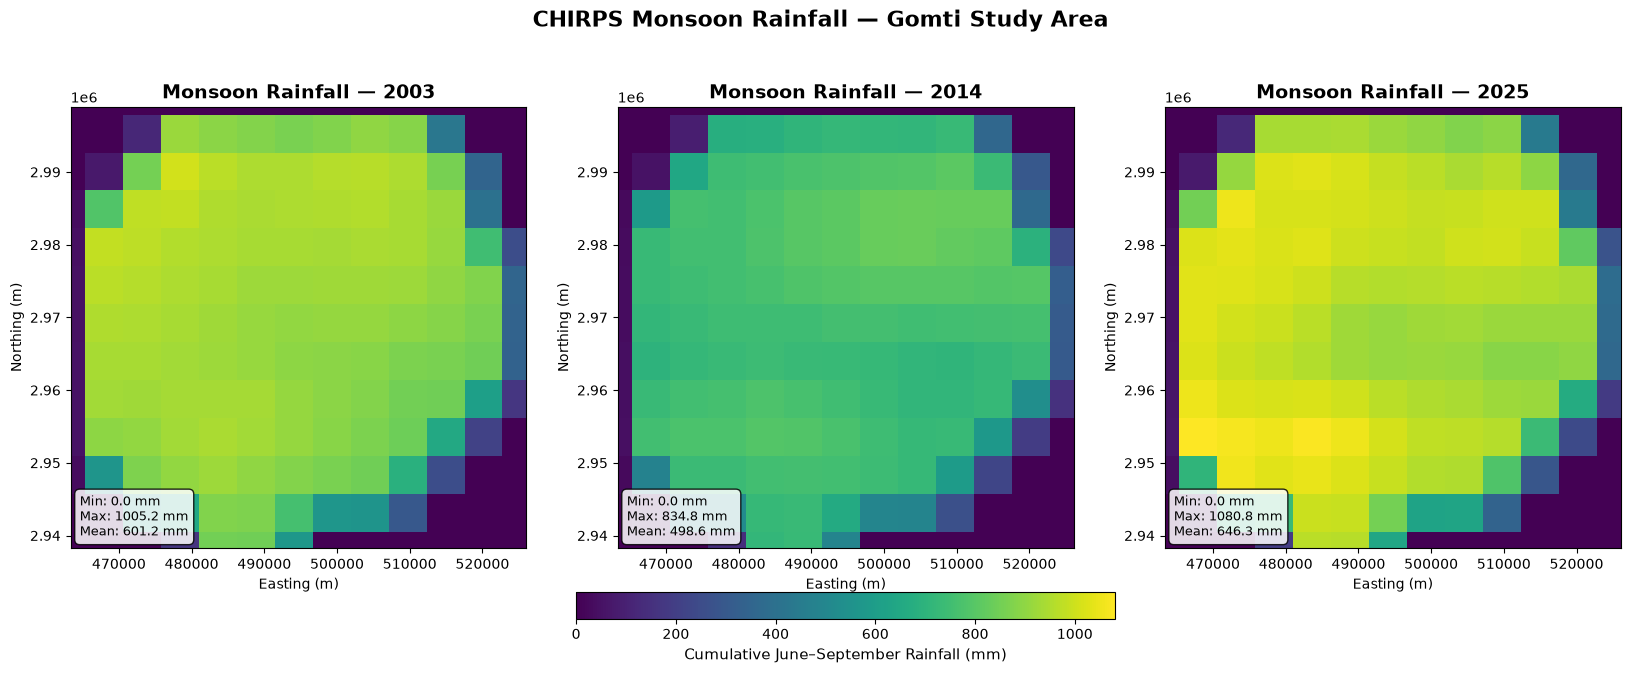


✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_05\CHIRPS_monsoon_rainfall_QA_2003_2014_2025.png

CHIRPS MONSOON RAINFALL — STATISTICAL ANALYSIS

----------------------------------------------------------------------
2003
----------------------------------------------------------------------
Valid pixels  : 169
Minimum (mm)  : 0.00
Maximum (mm)  : 1005.21
Mean (mm)     : 601.23
Median (mm)   : 866.73
Std. dev. (mm): 402.23

----------------------------------------------------------------------
2014
----------------------------------------------------------------------
Valid pixels  : 169
Minimum (mm)  : 0.00
Maximum (mm)  : 834.80
Mean (mm)     : 498.64
Median (mm)   : 718.57
Std. dev. (mm): 332.02

----------------------------------------------------------------------
2025
----------------------------------------------------------------------
Valid pixels  : 169
Minimum (mm)  : 0.00
Maximum (mm)  : 1080.84
Mean (mm)     : 646.31
Median (mm)   : 918.40


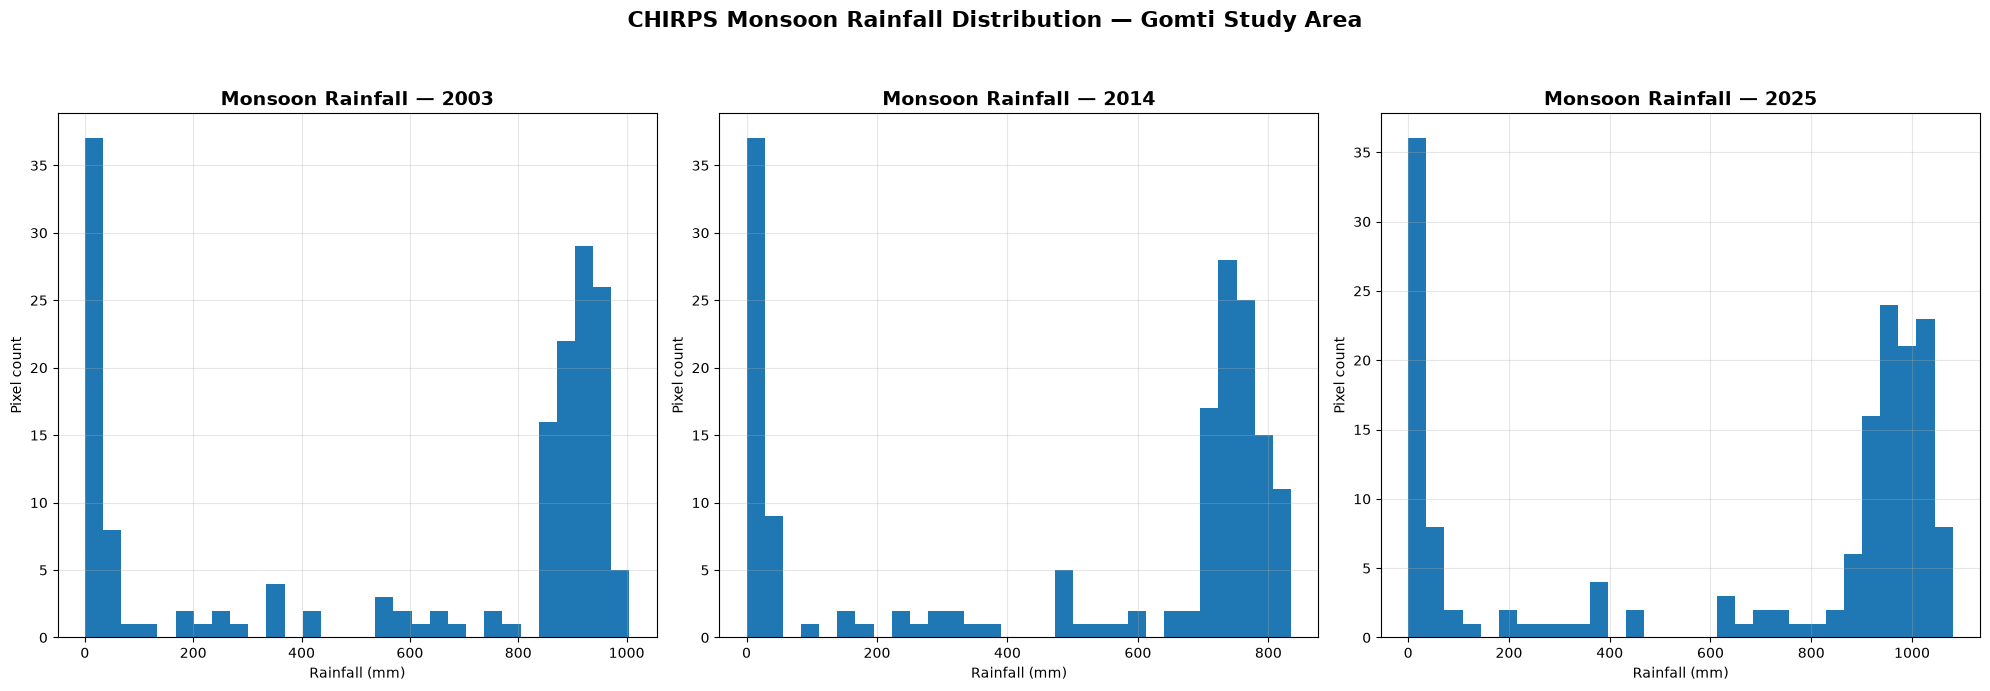


RAINFALL STATISTICAL OUTPUTS

✓ CSV saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\rainfall_statistics\CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.csv

✓ PNG saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_05\CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.png

✓ RAINFALL STATISTICAL ANALYSIS COMPLETED


In [56]:
# ============================================================
# Step 05.14 — Monsoon Rainfall QA and Visualization
# ============================================================

from matplotlib.colors import Normalize

# ------------------------------------------------------------
# Notebook 05 figure directory
# ------------------------------------------------------------

NB05_FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_05"
)

NB05_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Final rainfall raster paths
# ------------------------------------------------------------

monsoon_rainfall_paths = {
    year: (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / f"CHIRPS_monsoon_rainfall_{year}.tif"
    )
    for year in chirps_years
}

# ------------------------------------------------------------
# QA
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — MONSOON RAINFALL QA")
print("=" * 70)

reference = None
rainfall_stats = {}

for year in chirps_years:

    path = monsoon_rainfall_paths[year]

    if not path.exists():
        raise FileNotFoundError(
            f"Monsoon rainfall raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        data = src.read(1)

        finite = data[
            np.isfinite(data)
        ]

        if len(finite) == 0:
            raise ValueError(
                f"No finite rainfall values found:\n{path}"
            )

        current = {
            "shape": src.shape,
            "crs": src.crs,
            "transform": src.transform,
            "resolution": src.res,
            "bounds": src.bounds,
            "count": src.count,
            "dtype": src.dtypes[0]
        }

        # ----------------------------------------------------
        # Spatial consistency
        # ----------------------------------------------------

        if reference is None:

            reference = current

        else:

            for key in [
                "shape",
                "crs",
                "transform",
                "resolution",
                "bounds"
            ]:

                if current[key] != reference[key]:

                    raise ValueError(
                        f"Spatial mismatch for {year}: "
                        f"{key}"
                    )

        rainfall_stats[year] = {
            "min_mm": float(finite.min()),
            "max_mm": float(finite.max()),
            "mean_mm": float(finite.mean()),
            "finite_pixels": int(len(finite))
        }

        print("\n" + "-" * 70)
        print(f"YEAR — {year}")
        print("-" * 70)

        print(f"Shape       : {src.shape}")
        print(f"CRS         : {src.crs}")
        print(f"Resolution  : {src.res}")
        print(f"Bounds      : {src.bounds}")
        print(f"Data type   : {src.dtypes[0]}")
        print(f"Min rainfall: {finite.min():.2f} mm")
        print(f"Max rainfall: {finite.max():.2f} mm")
        print(f"Mean rainfall: {finite.mean():.2f} mm")
        print(f"Finite pixels: {len(finite):,}")

print("\n" + "=" * 70)
print("✓ ALL THREE MONSOON RAINFALL RASTERS PASSED SPATIAL QA")
print("=" * 70)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)

# ------------------------------------------------------------
# Common color scale
# ------------------------------------------------------------

global_max = max(
    stats["max_mm"]
    for stats in rainfall_stats.values()
)

norm = Normalize(
    vmin=0,
    vmax=global_max
)

study_bounds = study_area_gdf.total_bounds

for ax, year in zip(
    axes,
    chirps_years
):

    path = monsoon_rainfall_paths[year]

    with rasterio.open(path) as src:

        rainfall = src.read(1)

        # Mask non-finite values
        rainfall_display = np.where(
            np.isfinite(rainfall),
            rainfall,
            np.nan
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

        image = ax.imshow(
            rainfall_display,
            cmap="viridis",
            norm=norm,
            extent=extent,
            interpolation="none"
        )

    # --------------------------------------------------------
    # Study-area extent
    # --------------------------------------------------------

    ax.set_xlim(
        study_bounds[0],
        study_bounds[2]
    )

    ax.set_ylim(
        study_bounds[1],
        study_bounds[3]
    )

    ax.set_title(
        f"Monsoon Rainfall — {year}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    # --------------------------------------------------------
    # Statistics box
    # --------------------------------------------------------

    stats = rainfall_stats[year]

    text = (
        f"Min: {stats['min_mm']:.1f} mm\n"
        f"Max: {stats['max_mm']:.1f} mm\n"
        f"Mean: {stats['mean_mm']:.1f} mm"
    )

    ax.text(
        0.02,
        0.02,
        text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            alpha=0.85
        )
    )

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    image,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)

cbar.set_label(
    "Cumulative June–September Rainfall (mm)",
    fontsize=11
)

fig.suptitle(
    "CHIRPS Monsoon Rainfall — Gomti Study Area",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

rainfall_qa_figure = (
    NB05_FIGURES_DIR
    / "CHIRPS_monsoon_rainfall_QA_2003_2014_2025.png"
)

plt.savefig(
    rainfall_qa_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Figure saved:")
print(rainfall_qa_figure)


# ============================================================
# Rainfall Statistical Analysis — 2003, 2014, 2025
# ============================================================

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Final monsoon rainfall raster paths
# ------------------------------------------------------------

rainfall_paths = {
    2003: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "rainfall"
        / "CHIRPS_monsoon_rainfall_2003.tif"
    ),

    2014: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "rainfall"
        / "CHIRPS_monsoon_rainfall_2014.tif"
    ),

    2025: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "rainfall"
        / "CHIRPS_monsoon_rainfall_2025.tif"
    )
}

# ------------------------------------------------------------
# Read rainfall rasters and calculate statistics
# ------------------------------------------------------------

rainfall_data = {}
rainfall_statistics = []

print("\n" + "=" * 70)
print("CHIRPS MONSOON RAINFALL — STATISTICAL ANALYSIS")
print("=" * 70)

for year, path in rainfall_paths.items():

    if not path.exists():
        # The final rasters are stored inside year-specific directories.
        corrected_path = (
            RAINFALL_PROCESSED_DIR
            / str(year)
            / f"CHIRPS_monsoon_rainfall_{year}.tif"
        )

        if corrected_path.exists():
            path = corrected_path
            rainfall_paths[year] = corrected_path
        else:
            raise FileNotFoundError(
            f"Rainfall raster not found:\n"
            f"Checked:\n{path}\n"
            f"and:\n{corrected_path}"
            )

    with rasterio.open(path) as src:

        data = src.read(1).astype(np.float32)

        # ----------------------------------------------------
        # Valid pixels
        # ----------------------------------------------------

        valid = np.isfinite(data)

        if src.nodata is not None:
            valid &= data != src.nodata

        values = data[valid]

        if values.size == 0:
            raise ValueError(
                f"No valid rainfall pixels found for {year}."
            )

        rainfall_data[year] = values

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        rainfall_statistics.append({
            "year": year,
            "unit": "mm",
            "minimum": float(values.min()),
            "maximum": float(values.max()),
            "mean": float(values.mean()),
            "median": float(np.median(values)),
            "standard_deviation": float(values.std()),
            "valid_pixels": int(values.size)
        })

        print("\n" + "-" * 70)
        print(f"{year}")
        print("-" * 70)

        print(f"Valid pixels  : {values.size:,}")
        print(f"Minimum (mm)  : {values.min():.2f}")
        print(f"Maximum (mm)  : {values.max():.2f}")
        print(f"Mean (mm)     : {values.mean():.2f}")
        print(f"Median (mm)   : {np.median(values):.2f}")
        print(f"Std. dev. (mm): {values.std():.2f}")

# ------------------------------------------------------------
# Create statistics table
# ------------------------------------------------------------

rainfall_statistics_df = pd.DataFrame(
    rainfall_statistics
)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

rainfall_statistics_dir = (
    TABLES_DIR
    / "rainfall_statistics"
)

rainfall_statistics_dir.mkdir(
    parents=True,
    exist_ok=True
)

rainfall_statistics_csv = (
    rainfall_statistics_dir
    / "CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.csv"
)

rainfall_statistics_df.to_csv(
    rainfall_statistics_csv,
    index=False
)

# ------------------------------------------------------------
# Statistical visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)

for ax, year in zip(
    axes,
    [2003, 2014, 2025]
):

    values = rainfall_data[year]

    ax.hist(
        values,
        bins=30
    )

    ax.set_title(
        f"Monsoon Rainfall — {year}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Rainfall (mm)"
    )

    ax.set_ylabel(
        "Pixel count"
    )

    ax.grid(
        alpha=0.3
    )

fig.suptitle(
    "CHIRPS Monsoon Rainfall Distribution — Gomti Study Area",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

# ------------------------------------------------------------
# Save PNG
# ------------------------------------------------------------

rainfall_statistics_figure = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_05"
    / "CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.png"
)

rainfall_statistics_figure.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    rainfall_statistics_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Final output
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RAINFALL STATISTICAL OUTPUTS")
print("=" * 70)

print("\n✓ CSV saved:")
print(rainfall_statistics_csv)

print("\n✓ PNG saved:")
print(rainfall_statistics_figure)

print("\n" + "=" * 70)
print("✓ RAINFALL STATISTICAL ANALYSIS COMPLETED")
print("=" * 70)

## 5.15 — SoilGrids Coverage Verification

Before downloading the soil datasets, the available SoilGrids WCS coverage identifiers were verified directly from the official SoilGrids WCS services.

For this study, the surface-soil texture variables selected are:

- **Clay content:** `clay_0-5cm_mean`
- **Sand content:** `sand_0-5cm_mean`

Both datasets represent the **0–5 cm soil depth** and use the SoilGrids **mean prediction**.

The live WCS service confirmed the availability of the following coverage identifiers:

### Clay

- `clay_0-5cm_Q0.05`
- `clay_0-5cm_Q0.5`
- `clay_0-5cm_Q0.95`
- `clay_0-5cm_mean`
- `clay_0-5cm_uncertainty`

### Sand

- `sand_0-5cm_Q0.05`
- `sand_0-5cm_Q0.5`
- `sand_0-5cm_Q0.95`
- `sand_0-5cm_mean`
- `sand_0-5cm_uncertainty`

The `mean` coverage was selected for both properties because the objective is to use the predicted soil-property values as environmental predictors in the flood-susceptibility analysis.

The datasets will be spatially subset to the existing Lucknow study area rather than downloading the global SoilGrids rasters.

In [57]:
# ============================================================
# Step 05.15 — Verify SoilGrids Coverage IDs
# ============================================================

import requests
import xml.etree.ElementTree as ET

soilgrids_services = {
    "clay": "https://maps.isric.org/mapserv?map=/map/clay.map",
    "sand": "https://maps.isric.org/mapserv?map=/map/sand.map"
}

print("\n" + "=" * 70)
print("SOILGRIDS — COVERAGE VERIFICATION")
print("=" * 70)

for property_name, service_url in soilgrids_services.items():

    params = {
        "SERVICE": "WCS",
        "VERSION": "2.0.1",
        "REQUEST": "GetCapabilities"
    }

    response = requests.get(
        service_url,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    root = ET.fromstring(response.content)

    coverage_ids = []

    for element in root.iter():
        if element.tag.endswith("CoverageId"):
            coverage_ids.append(
                element.text
            )

    print(f"\n{property_name.upper()}")
    print("-" * 50)

    for coverage_id in coverage_ids:
        if coverage_id and "0-5cm" in coverage_id:
            print(coverage_id)

print("\n" + "=" * 70)


SOILGRIDS — COVERAGE VERIFICATION

CLAY
--------------------------------------------------
clay_0-5cm_Q0.05
clay_0-5cm_Q0.5
clay_0-5cm_Q0.95
clay_0-5cm_mean
clay_0-5cm_uncertainty

SAND
--------------------------------------------------
sand_0-5cm_Q0.05
sand_0-5cm_Q0.5
sand_0-5cm_Q0.95
sand_0-5cm_mean
sand_0-5cm_uncertainty



## 5.16 — Download SoilGrids Soil-Texture Data

The selected soil datasets were downloaded from the official ISRIC SoilGrids
Web Coverage Service (WCS).

Two surface-soil texture properties were selected:

- Clay content: `clay_0-5cm_mean`
- Sand content: `sand_0-5cm_mean`

Both datasets represent the mean SoilGrids prediction for the 0–5 cm depth
interval at the native SoilGrids spatial resolution of approximately 250 m.

The existing study-area geometry already transformed to EPSG:4326 during the
CHIRPS preprocessing workflow is reused for defining the WCS spatial subset.
The original study-area dataset is therefore not reloaded.

Only the spatial extent covering the Lucknow study area is requested from the
global SoilGrids service. The downloaded source subsets are stored in the
project's raw soil-data directory and will be processed and harmonized in
subsequent steps.

The SoilGrids WCS service is used because it supports spatial subsetting of
individual soil-property predictions for modelling workflows.

In [58]:
# ============================================================
# Step 05.16 — Download SoilGrids Clay and Sand
# ============================================================

import requests
import rasterio

# ------------------------------------------------------------
# Check that the existing WGS84 study-area object is available
# ------------------------------------------------------------

if "study_area_chirps" not in globals():
    raise NameError(
        "study_area_chirps is not available. "
        "Do not reload the study area yet; verify the previous "
        "study-area transformation cell first."
    )

if study_area_chirps.crs is None:
    raise ValueError(
        "study_area_chirps has no CRS."
    )

if study_area_chirps.crs.to_string() != "EPSG:4326":
    raise ValueError(
        f"Expected study_area_chirps to be EPSG:4326, "
        f"but found {study_area_chirps.crs}"
    )

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

soil_raw_dir = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "soil"
)

soil_raw_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Study-area bounding box
# ------------------------------------------------------------

west, south, east, north = (
    study_area_chirps.total_bounds
)

print("\n" + "=" * 70)
print("NOTEBOOK 05 — SOILGRIDS DOWNLOAD")
print("=" * 70)

print("\nStudy-area CRS:", study_area_chirps.crs)

print("\nWCS spatial subset:")
print(f"West  : {west:.8f}")
print(f"South : {south:.8f}")
print(f"East  : {east:.8f}")
print(f"North : {north:.8f}")

# ------------------------------------------------------------
# SoilGrids services and coverage IDs
# ------------------------------------------------------------

soilgrids_layers = {
    "clay": {
        "service": (
            "https://maps.isric.org/mapserv"
            "?map=/map/clay.map"
        ),
        "coverage": "clay_0-5cm_mean",
        "output": soil_raw_dir / "clay_0-5cm_mean.tif"
    },

    "sand": {
        "service": (
            "https://maps.isric.org/mapserv"
            "?map=/map/sand.map"
        ),
        "coverage": "sand_0-5cm_mean",
        "output": soil_raw_dir / "sand_0-5cm_mean.tif"
    }
}

# ------------------------------------------------------------
# CRS identifiers used by WCS
# ------------------------------------------------------------

wgs84_crs_uri = (
    "http://www.opengis.net/def/crs/EPSG/0/4326"
)

# ------------------------------------------------------------
# Download each SoilGrids layer
# ------------------------------------------------------------

for property_name, config in soilgrids_layers.items():

    print("\n" + "-" * 70)
    print(f"DOWNLOADING — {property_name.upper()}")
    print("-" * 70)

    output_path = config["output"]

    params = [
        ("SERVICE", "WCS"),
        ("VERSION", "2.0.1"),
        ("REQUEST", "GetCoverage"),
        ("COVERAGEID", config["coverage"]),
        ("FORMAT", "GEOTIFF_INT16"),

        # Spatial subset in geographic coordinates
        ("SUBSET", f"X({west},{east})"),
        ("SUBSET", f"Y({south},{north})"),

        # Input/request CRS
        ("SUBSETTINGCRS", wgs84_crs_uri),

        # Output CRS
        ("OUTPUTCRS", wgs84_crs_uri)
    ]

    print("Coverage:", config["coverage"])
    print("Output :", output_path)

    response = requests.get(
        config["service"],
        params=params,
        timeout=180
    )

    response.raise_for_status()

    content_type = response.headers.get(
        "Content-Type",
        ""
    ).lower()

    # --------------------------------------------------------
    # Protect against saving an XML WCS error as a .tif
    # --------------------------------------------------------

    if (
        "xml" in content_type
        or response.content.startswith(b"<?xml")
    ):
        print("\nWCS returned an XML response instead of a GeoTIFF.")
        print(response.text[:2000])

        raise RuntimeError(
            f"SoilGrids WCS download failed for {property_name}."
        )

    # --------------------------------------------------------
    # Save GeoTIFF
    # --------------------------------------------------------

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(
        f"Downloaded: "
        f"{output_path.name} "
        f"({output_path.stat().st_size / (1024**2):.2f} MB)"
    )

    # --------------------------------------------------------
    # Immediate raster verification
    # --------------------------------------------------------

    with rasterio.open(output_path) as src:

        print("Shape      :", src.shape)
        print("Bands      :", src.count)
        print("CRS        :", src.crs)
        print("Resolution :", src.res)
        print("Bounds     :", src.bounds)
        print("Data type  :", src.dtypes[0])

print("\n" + "=" * 70)
print("✓ SOILGRIDS CLAY AND SAND DOWNLOAD COMPLETED")
print("=" * 70)


NOTEBOOK 05 — SOILGRIDS DOWNLOAD

Study-area CRS: EPSG:4326

WCS spatial subset:
West  : 80.63094766
South : 26.56460452
East  : 81.26238009
North : 27.11338905

----------------------------------------------------------------------
DOWNLOADING — CLAY
----------------------------------------------------------------------
Coverage: clay_0-5cm_mean
Output : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\soil\clay_0-5cm_mean.tif
Downloaded: clay_0-5cm_mean.tif (0.05 MB)
Shape      : (230, 279)
Bands      : 1
CRS        : EPSG:4326
Resolution : (0.002263198675156459, 0.002386019703420866)
Bounds     : BoundingBox(left=80.63094766281651, bottom=26.564604522423107, right=81.26238009318516, top=27.113389054209907)
Data type  : int16

----------------------------------------------------------------------
DOWNLOADING — SAND
----------------------------------------------------------------------
Coverage: sand_0-5cm_mean
Output : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\soil\sand_0-5cm_m

## 5.17 — SoilGrids Raw Raster Quality Assurance

The downloaded SoilGrids clay and sand rasters are subjected to an initial
quality-assurance check before any reprojection, resampling, clipping, or
unit conversion.

For each raster, the following properties are inspected:

- Raster dimensions
- Number of bands
- Coordinate reference system
- Spatial resolution
- Spatial bounds
- Data type
- NoData value
- Finite pixel count
- Minimum and maximum values
- Mean value

The purpose of this step is to confirm that the WCS downloads are valid,
spatially consistent, and contain plausible soil-property values.

The original downloaded rasters are retained unchanged in the raw soil-data
directory. Any subsequent unit conversion or spatial harmonization will be
performed on separate processed copies.

In [59]:
# ============================================================
# Step 05.17 — SoilGrids Raw Raster QA
# ============================================================

import numpy as np
import rasterio

# ------------------------------------------------------------
# Raw SoilGrids files
# ------------------------------------------------------------

soil_raw_paths = {
    "Clay": (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "soil"
        / "clay_0-5cm_mean.tif"
    ),

    "Sand": (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "soil"
        / "sand_0-5cm_mean.tif"
    )
}

# ------------------------------------------------------------
# QA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOTEBOOK 05 — SOILGRIDS RAW RASTER QA")
print("=" * 70)

for property_name, path in soil_raw_paths.items():

    print("\n" + "-" * 70)
    print(f"{property_name.upper()} — RAW RASTER")
    print("-" * 70)

    if not path.exists():
        raise FileNotFoundError(
            f"Required SoilGrids raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        data = src.read(1)

        # ----------------------------------------------------
        # Valid / finite pixels
        # ----------------------------------------------------

        finite_mask = np.isfinite(data)

        if src.nodata is not None:
            valid_mask = (
                finite_mask &
                (data != src.nodata)
            )
        else:
            valid_mask = finite_mask

        valid_data = data[valid_mask]

        if valid_data.size == 0:
            raise ValueError(
                f"No valid pixels found in {property_name} raster."
            )

        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        print(f"File         : {path.name}")
        print(f"Shape        : {src.shape}")
        print(f"Bands        : {src.count}")
        print(f"CRS          : {src.crs}")
        print(f"Resolution   : {src.res}")
        print(f"Bounds       : {src.bounds}")
        print(f"Data type    : {src.dtypes[0]}")
        print(f"NoData       : {src.nodata}")

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        print(f"Finite pixels: {finite_mask.sum():,}")
        print(f"Valid pixels : {valid_data.size:,}")

        print(
            f"Minimum      : "
            f"{valid_data.min():.2f}"
        )

        print(
            f"Maximum      : "
            f"{valid_data.max():.2f}"
        )

        print(
            f"Mean         : "
            f"{valid_data.mean():.2f}"
        )

        print(
            f"Median       : "
            f"{np.median(valid_data):.2f}"
        )

print("\n" + "=" * 70)
print("✓ SOILGRIDS RAW RASTER QA COMPLETED")
print("=" * 70)


NOTEBOOK 05 — SOILGRIDS RAW RASTER QA

----------------------------------------------------------------------
CLAY — RAW RASTER
----------------------------------------------------------------------
File         : clay_0-5cm_mean.tif
Shape        : (230, 279)
Bands        : 1
CRS          : EPSG:4326
Resolution   : (0.002263198675156459, 0.002386019703420866)
Bounds       : BoundingBox(left=80.63094766281651, bottom=26.564604522423107, right=81.26238009318516, top=27.113389054209907)
Data type    : int16
NoData       : None
Finite pixels: 64,170
Valid pixels : 64,170
Minimum      : 0.00
Maximum      : 342.00
Mean         : 255.99
Median       : 266.00

----------------------------------------------------------------------
SAND — RAW RASTER
----------------------------------------------------------------------
File         : sand_0-5cm_mean.tif
Shape        : (230, 279)
Bands        : 1
CRS          : EPSG:4326
Resolution   : (0.002263198675156459, 0.002386019703420866)
Bounds       : 

## 5.18 — SoilGrids Clipping and Unit Conversion

The downloaded SoilGrids clay and sand rasters are provided in EPSG:4326 and
represent the 0–5 cm mean soil-property predictions.

The raw rasters are retained unchanged in the raw-data directory.

The existing study-area geometry is used to spatially clip the SoilGrids
rasters to the Lucknow study area. Since the SoilGrids rasters are already
provided in EPSG:4326, no reprojection is required before clipping.

After clipping, the SoilGrids soil-texture values are converted from g/kg to
percentage using:

\[
\text{Soil content (\%)} =
\frac{\text{Soil content (g/kg)}}{10}
\]

The converted clay and sand layers are then prepared for reprojection to the
project CRS, EPSG:32644.

The final spatial harmonization to EPSG:32644 is performed in the subsequent
processing step.

In [60]:
# ============================================================
# Step 05.18 — SoilGrids Clipping + Unit Conversion
# ============================================================

import numpy as np
import rasterio
from rasterio.mask import mask

# ------------------------------------------------------------
# SoilGrids raw input paths
# ------------------------------------------------------------

soil_raw_paths = {
    "Clay": (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "soil"
        / "clay_0-5cm_mean.tif"
    ),

    "Sand": (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "soil"
        / "sand_0-5cm_mean.tif"
    )
}

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

soil_processed_dir = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
    / "soil"
)

soil_processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# SoilGrids conversion
#
# SoilGrids texture values:
# g/kg
#
# Percentage:
# g/kg ÷ 10
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOTEBOOK 05 — SOILGRIDS CLIPPING + UNIT CONVERSION")
print("=" * 70)

for property_name, input_path in soil_raw_paths.items():

    print("\n" + "-" * 70)
    print(f"PROCESSING — {property_name.upper()}")
    print("-" * 70)

    if not input_path.exists():
        raise FileNotFoundError(
            f"Raw SoilGrids raster not found:\n{input_path}"
        )

    with rasterio.open(input_path) as src:

        # ----------------------------------------------------
        # Ensure source CRS is expected CRS
        # ----------------------------------------------------

        if src.crs is None:
            raise ValueError(
                f"{property_name} raster has no CRS."
            )

        if src.crs.to_string() != "EPSG:4326":
            raise ValueError(
                f"Expected {property_name} SoilGrids raster "
                f"in EPSG:4326, found {src.crs}"
            )

        # ----------------------------------------------------
        # Clip using the EXISTING study area in EPSG:4326
        #
        # study_area_chirps was already created earlier.
        # We reuse it instead of reprojecting the study area again.
        # ----------------------------------------------------

        study_geometries = (
            study_area_chirps.geometry
            .tolist()
        )

        clipped, clipped_transform = mask(
            src,
            study_geometries,
            crop=True,
            filled=False
        )

        # ----------------------------------------------------
        # Convert masked array to float32
        # ----------------------------------------------------

        clipped = clipped[0].astype(
            np.float32
        )

        # ----------------------------------------------------
        # Convert g/kg → %
        # ----------------------------------------------------

        clipped_percent = (
            clipped / 10.0
        )

        # ----------------------------------------------------
        # Preserve mask
        # ----------------------------------------------------

        clipped_percent = np.ma.masked_array(
            clipped_percent,
            mask=np.ma.getmaskarray(clipped)
        )

        # ----------------------------------------------------
        # Output profile
        # ----------------------------------------------------

        output_path = (
            soil_processed_dir
            / f"{property_name.lower()}_0-5cm_percent_clipped.tif"
        )

        profile = src.profile.copy()

        profile.update(
            driver="GTiff",
            height=clipped_percent.shape[0],
            width=clipped_percent.shape[1],
            transform=clipped_transform,
            crs=src.crs,
            dtype="float32",
            count=1,
            nodata=-9999.0,
            compress="deflate"
        )

        # ----------------------------------------------------
        # Write raster
        # ----------------------------------------------------

        output_array = clipped_percent.filled(
            -9999.0
        )

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            dst.write(
                output_array,
                1
            )

        # ----------------------------------------------------
        # QA
        # ----------------------------------------------------

        valid = (
            output_array != -9999.0
        )

        valid_values = output_array[valid]

        print(
            f"Output       : {output_path.name}"
        )

        print(
            f"Shape        : {output_array.shape}"
        )

        print(
            f"CRS          : {src.crs}"
        )

        print(
            f"NoData       : -9999.0"
        )

        print(
            f"Valid pixels : {valid_values.size:,}"
        )

        print(
            f"Minimum (%)  : {valid_values.min():.2f}"
        )

        print(
            f"Maximum (%)  : {valid_values.max():.2f}"
        )

        print(
            f"Mean (%)     : {valid_values.mean():.2f}"
        )

print("\n" + "=" * 70)
print("✓ SOILGRIDS CLIPPED WITH EXPLICIT NODATA")
print("✓ SOILGRIDS CONVERTED FROM g/kg TO %")
print("✓ ORIGINAL RAW RASTERS WERE NOT MODIFIED")
print("=" * 70)


NOTEBOOK 05 — SOILGRIDS CLIPPING + UNIT CONVERSION

----------------------------------------------------------------------
PROCESSING — CLAY
----------------------------------------------------------------------
Output       : clay_0-5cm_percent_clipped.tif
Shape        : (230, 279)
CRS          : EPSG:4326
NoData       : -9999.0
Valid pixels : 50,210
Minimum (%)  : 0.00
Maximum (%)  : 34.20
Mean (%)     : 25.17

----------------------------------------------------------------------
PROCESSING — SAND
----------------------------------------------------------------------
Output       : sand_0-5cm_percent_clipped.tif
Shape        : (230, 279)
CRS          : EPSG:4326
NoData       : -9999.0
Valid pixels : 50,210
Minimum (%)  : 0.00
Maximum (%)  : 42.90
Mean (%)     : 32.07

✓ SOILGRIDS CLIPPED WITH EXPLICIT NODATA
✓ SOILGRIDS CONVERTED FROM g/kg TO %
✓ ORIGINAL RAW RASTERS WERE NOT MODIFIED


## 5.19 — SoilGrids Reprojection and Visualization

The clipped and unit-converted SoilGrids clay and sand rasters are
reprojected from EPSG:4326 to the project's working CRS, EPSG:32644.

The reprojection is performed after clipping and unit conversion so that the
final soil layers are spatially compatible with the other project datasets.

The native SoilGrids spatial information is retained; the soil layers are
not artificially resampled to the 30 m resolution of the optical/LULC data
at this stage.

The final clay and sand layers are saved in the Notebook 05 processed-soil
directory.

For visual quality assessment, both soil-property layers are plotted using
the same study-area extent. The resulting figure is saved in the
Notebook 05 figures directory.


NOTEBOOK 05 — SOILGRIDS REPROJECTION

----------------------------------------------------------------------
REPROJECTING — CLAY
----------------------------------------------------------------------
Output      : clay_0-5cm_percent_EPSG32644.tif
Shape       : (252, 260)
CRS         : EPSG:32644
Resolution  : (241.58204636188105, 241.58204636188105)
Bounds      : BoundingBox(left=463244.28811278613, bottom=2938169.2396807703, right=526055.6201668752, top=2999047.915363964)
Min (%)     : -9999.00
Max (%)     : 34.01
Mean (%)    : -2174.88

----------------------------------------------------------------------
REPROJECTING — SAND
----------------------------------------------------------------------
Output      : sand_0-5cm_percent_EPSG32644.tif
Shape       : (252, 260)
CRS         : EPSG:32644
Resolution  : (241.58204636188105, 241.58204636188105)
Bounds      : BoundingBox(left=463244.28811278613, bottom=2938169.2396807703, right=526055.6201668752, top=2999047.915363964)
Min (%)     : 

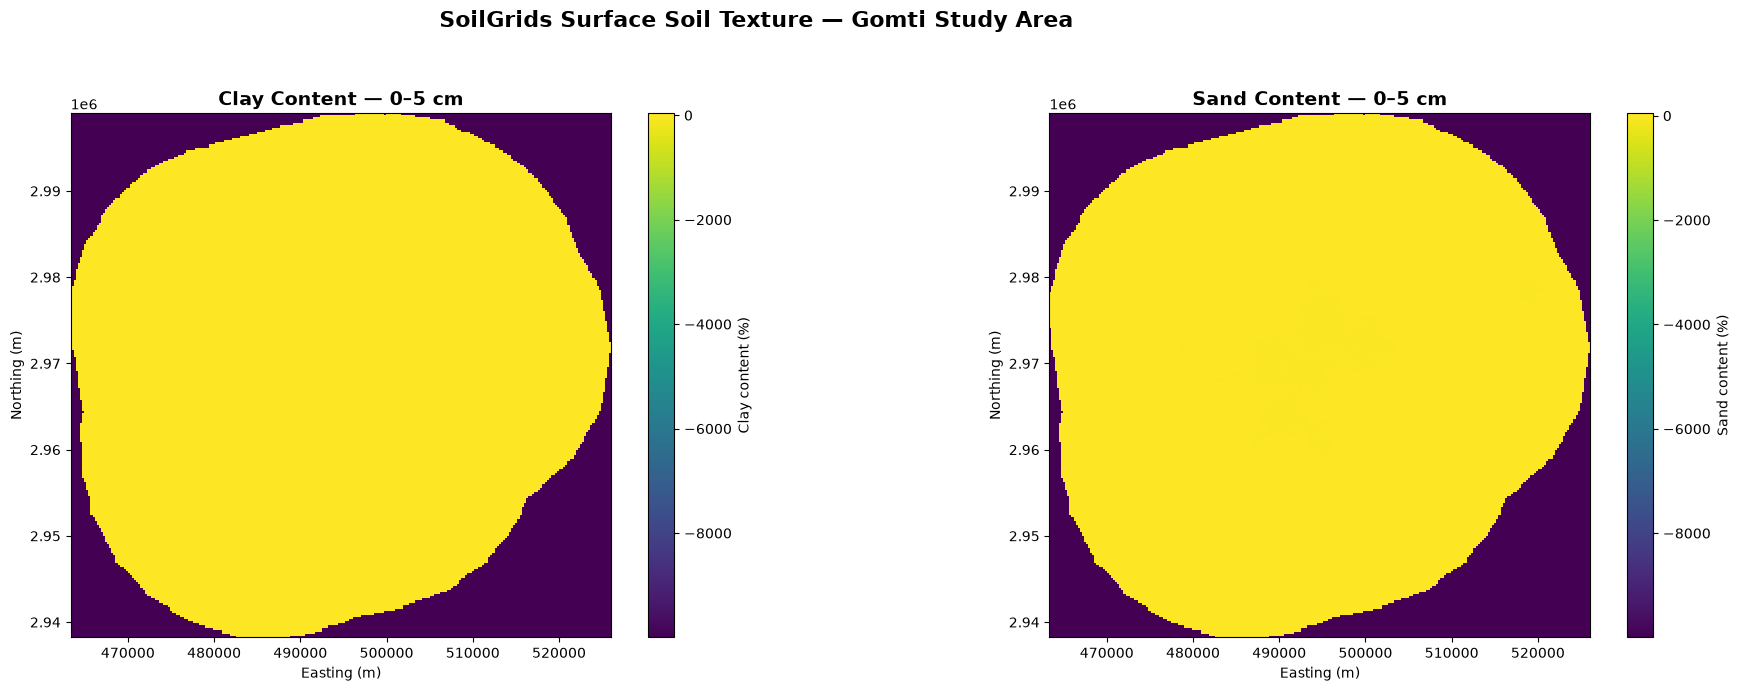


✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_05\SoilGrids_clay_sand_0-5cm_2003_2014_2025.png


In [61]:
# ============================================================
# Step 05.19 — Reproject and Visualize SoilGrids
# ============================================================

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.warp import calculate_default_transform, reproject, Resampling

# ------------------------------------------------------------
# Input paths
# ------------------------------------------------------------

soil_input_paths = {
    "Clay": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "clay_0-5cm_percent_clipped.tif"
    ),

    "Sand": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "sand_0-5cm_percent_clipped.tif"
    )
}

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

soil_output_paths = {
    property_name: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / f"{property_name.lower()}_0-5cm_percent_EPSG32644.tif"
    )
    for property_name in soil_input_paths
}

# ------------------------------------------------------------
# Target CRS
# ------------------------------------------------------------

target_crs = "EPSG:32644"

print("\n" + "=" * 70)
print("NOTEBOOK 05 — SOILGRIDS REPROJECTION")
print("=" * 70)

# ------------------------------------------------------------
# Reproject Clay and Sand
# ------------------------------------------------------------

for property_name, input_path in soil_input_paths.items():

    if not input_path.exists():
        raise FileNotFoundError(
            f"Input soil raster not found:\n{input_path}"
        )

    output_path = soil_output_paths[property_name]

    print("\n" + "-" * 70)
    print(f"REPROJECTING — {property_name.upper()}")
    print("-" * 70)

    with rasterio.open(input_path) as src:

        if src.crs is None:
            raise ValueError(
                f"{property_name} raster has no CRS."
            )

        if src.crs.to_string() != "EPSG:4326":
            raise ValueError(
                f"Expected {property_name} input to be EPSG:4326, "
                f"found {src.crs}"
            )

        # ----------------------------------------------------
        # Calculate target grid
        # ----------------------------------------------------

        transform, width, height = (
            calculate_default_transform(
                src.crs,
                target_crs,
                src.width,
                src.height,
                *src.bounds
            )
        )

        profile = src.profile.copy()

        profile.update(
            crs=target_crs,
            transform=transform,
            width=width,
            height=height,
            dtype="float32",
            count=1,
            compress="deflate"
        )

        # ----------------------------------------------------
        # Create destination raster
        # ----------------------------------------------------

        with rasterio.open(
            output_path,
            "w",
            **profile
        ) as dst:

            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear
            )

    # --------------------------------------------------------
    # QA after reprojection
    # --------------------------------------------------------

    with rasterio.open(output_path) as src:

        data = src.read(1)

        valid = np.isfinite(data)

        values = data[valid]

        print(
            f"Output      : {output_path.name}"
        )

        print(
            f"Shape       : {src.shape}"
        )

        print(
            f"CRS         : {src.crs}"
        )

        print(
            f"Resolution  : {src.res}"
        )

        print(
            f"Bounds      : {src.bounds}"
        )

        print(
            f"Min (%)     : {values.min():.2f}"
        )

        print(
            f"Max (%)     : {values.max():.2f}"
        )

        print(
            f"Mean (%)    : {values.mean():.2f}"
        )

print("\n" + "=" * 70)
print("✓ CLAY AND SAND REPROJECTED TO EPSG:32644")
print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print("\n" + "=" * 70)
print("SOILGRIDS — FINAL SOIL PROPERTY VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 7)
)

study_bounds = study_area_gdf.to_crs(
    target_crs
).total_bounds

for ax, property_name in zip(
    axes,
    ["Clay", "Sand"]
):

    path = soil_output_paths[property_name]

    with rasterio.open(path) as src:

        data = src.read(1)

        display_data = np.where(
            np.isfinite(data),
            data,
            np.nan
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

        image = ax.imshow(
            display_data,
            extent=extent,
            cmap="viridis",
            interpolation="none"
        )

        cbar = fig.colorbar(
            image,
            ax=ax,
            fraction=0.046,
            pad=0.04
        )

        cbar.set_label(
            f"{property_name} content (%)",
            fontsize=10
        )

    # --------------------------------------------------------
    # Exact study-area view
    # --------------------------------------------------------

    ax.set_xlim(
        study_bounds[0],
        study_bounds[2]
    )

    ax.set_ylim(
        study_bounds[1],
        study_bounds[3]
    )

    ax.set_title(
        f"{property_name} Content — 0–5 cm",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    "SoilGrids Surface Soil Texture — Gomti Study Area",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

soil_figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_05"
    / "SoilGrids_clay_sand_0-5cm_2003_2014_2025.png"
)

soil_figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    soil_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Figure saved:")
print(soil_figure_path)

## 5.20 — Final SoilGrids Quality Assessment

The final processed SoilGrids clay and sand layers are subjected to a final
quality-assurance assessment after reprojection to the project CRS, EPSG:32644.

The assessment verifies the coordinate reference system, raster dimensions,
resolution, spatial extent, data type, valid-pixel count, and soil-property
statistics.

The clay and sand layers are also checked for spatial-grid consistency so
that both predictors occupy the same spatial framework.

The resulting value ranges are inspected to ensure that the reprojection
and bilinear resampling have not produced unrealistic soil-property values.

Only after this quality assessment are the soil layers considered ready for
integration into the flood-susceptibility modelling workflow.

In [62]:
# ============================================================
# Step 05.20 — Final SoilGrids QA
# ============================================================

import numpy as np
import rasterio

# ------------------------------------------------------------
# Final processed soil rasters
# ------------------------------------------------------------

final_soil_paths = {
    "Clay": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "clay_0-5cm_percent_EPSG32644.tif"
    ),

    "Sand": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "sand_0-5cm_percent_EPSG32644.tif"
    )
}

# ------------------------------------------------------------
# QA
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOTEBOOK 05 — FINAL SOILGRIDS QA")
print("=" * 70)

reference = None
soil_statistics = {}

for property_name, path in final_soil_paths.items():

    print("\n" + "-" * 70)
    print(f"{property_name.upper()} — FINAL PROCESSED RASTER")
    print("-" * 70)

    if not path.exists():
        raise FileNotFoundError(
            f"Final soil raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        data = src.read(1)

        # ----------------------------------------------------
        # Valid data
        # ----------------------------------------------------

        valid = (
           np.isfinite(data) &
           (data != -9999.0)
        )

        values = data[valid]

        if values.size == 0:
            raise ValueError(
                f"No valid pixels found in {property_name}."
            )

        # ----------------------------------------------------
        # Spatial information
        # ----------------------------------------------------

        current = {
            "shape": src.shape,
            "crs": src.crs,
            "transform": src.transform,
            "resolution": src.res,
            "bounds": src.bounds
        }

        if reference is None:

            reference = current

        else:

            for key in [
                "shape",
                "crs",
                "transform",
                "resolution",
                "bounds"
            ]:

                if current[key] != reference[key]:

                    raise ValueError(
                        f"{property_name} does not match "
                        f"the spatial grid for {key}."
                    )

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        soil_statistics[property_name] = {
            "min": float(values.min()),
            "max": float(values.max()),
            "mean": float(values.mean()),
            "median": float(np.median(values)),
            "valid_pixels": int(values.size)
        }

        print(f"File         : {path.name}")
        print(f"Shape        : {src.shape}")
        print(f"CRS          : {src.crs}")
        print(f"Resolution   : {src.res}")
        print(f"Bounds       : {src.bounds}")
        print(f"Data type    : {src.dtypes[0]}")
        print(f"Valid pixels : {values.size:,}")
        print(f"Minimum (%)  : {values.min():.2f}")
        print(f"Maximum (%)  : {values.max():.2f}")
        print(f"Mean (%)     : {values.mean():.2f}")
        print(f"Median (%)   : {np.median(values):.2f}")

        # ----------------------------------------------------
        # Basic physical-range check
        # ----------------------------------------------------

        if values.min() < 0 or values.max() > 100:

            raise ValueError(
                f"{property_name} contains values outside "
                f"the expected 0–100% range."
            )

print("\n" + "=" * 70)
print("✓ CLAY AND SAND PASSED VALUE-RANGE QA")
print("✓ CLAY AND SAND SHARE THE SAME SPATIAL GRID")
print("✓ FINAL SOIL LAYERS ARE READY FOR MODELLING")
print("=" * 70)


NOTEBOOK 05 — FINAL SOILGRIDS QA

----------------------------------------------------------------------
CLAY — FINAL PROCESSED RASTER
----------------------------------------------------------------------
File         : clay_0-5cm_percent_EPSG32644.tif
Shape        : (252, 260)
CRS          : EPSG:32644
Resolution   : (241.58204636188105, 241.58204636188105)
Bounds       : BoundingBox(left=463244.28811278613, bottom=2938169.2396807703, right=526055.6201668752, top=2999047.915363964)
Data type    : float32
Valid pixels : 51,140
Minimum (%)  : 0.00
Maximum (%)  : 34.01
Mean (%)     : 25.18
Median (%)   : 26.44

----------------------------------------------------------------------
SAND — FINAL PROCESSED RASTER
----------------------------------------------------------------------
File         : sand_0-5cm_percent_EPSG32644.tif
Shape        : (252, 260)
CRS          : EPSG:32644
Resolution   : (241.58204636188105, 241.58204636188105)
Bounds       : BoundingBox(left=463244.28811278613, b

## 5.21 — Soil Statistical Analysis

The final processed SoilGrids clay and sand layers are statistically
analysed before their integration into the flood-susceptibility modelling
workflow.

For each soil property, descriptive statistics including minimum, maximum,
mean, median, standard deviation, and valid-pixel count are calculated.

The Pearson correlation coefficient and corresponding p-value are calculated
between clay and sand content using corresponding valid raster pixels.

This analysis provides an initial assessment of the statistical relationship
between the two soil-texture predictors. It is exploratory and does not
assign flood-susceptibility weights or remove either variable solely on the
basis of correlation.

The spatial distribution of the soil properties was already visualized and
saved during the previous processing step. Therefore, this step focuses on
the numerical statistical assessment and records the results in a CSV table.


NOTEBOOK 05 — SOIL STATISTICAL ANALYSIS

----------------------------------------------------------------------
CLAY
----------------------------------------------------------------------
Valid pixels  : 65,520
Minimum (%)   : -9999.00
Maximum (%)   : 34.01
Mean (%)      : -2174.88
Median (%)    : 25.74
Std. dev. (%) : 4148.92

----------------------------------------------------------------------
SAND
----------------------------------------------------------------------
Valid pixels  : 65,520
Minimum (%)   : -9999.00
Maximum (%)   : 42.63
Mean (%)      : -2169.50
Median (%)    : 33.27
Std. dev. (%) : 4151.77

CLAY–SAND CORRELATION
Paired valid pixels : 65,520
Pearson r           : 1.0000
p-value             : 0.000000e+00


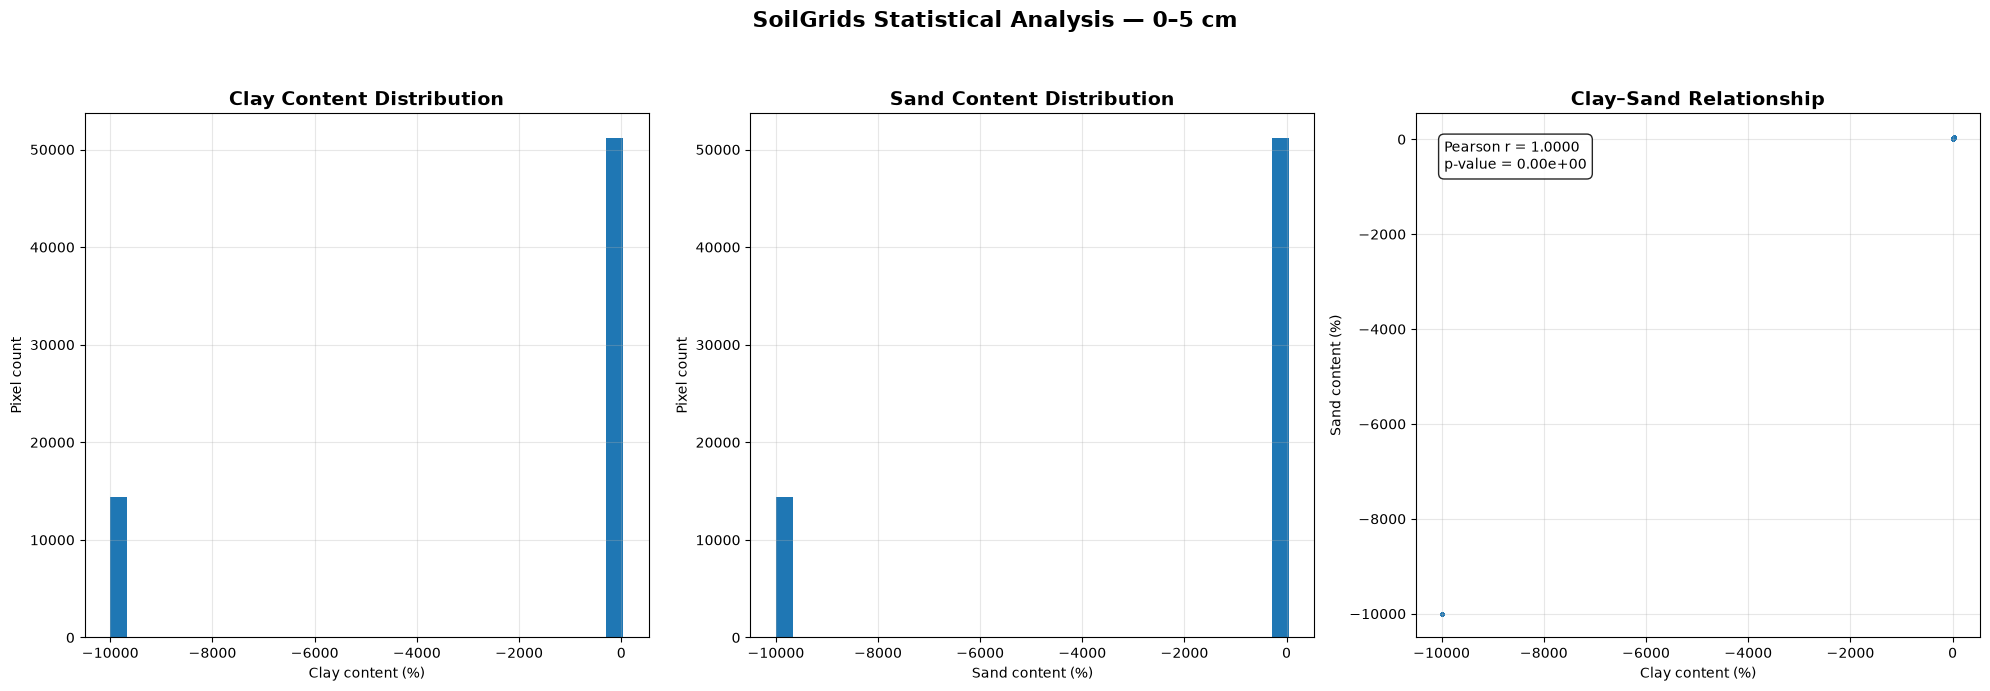


NOTEBOOK 05 — STATISTICAL OUTPUTS

✓ CSV saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\Soil_statistics\SoilGrids_soil_statistics_0-5cm.csv

✓ Statistical figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_05\SoilGrids_statistical_analysis_0-5cm.png

✓ SOIL STATISTICAL ANALYSIS COMPLETED


In [63]:
# ============================================================
# Step 05.21 — Soil Statistical Analysis
# ============================================================

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ------------------------------------------------------------
# Final processed soil raster paths
# ------------------------------------------------------------

soil_analysis_paths = {
    "Clay": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "clay_0-5cm_percent_EPSG32644.tif"
    ),

    "Sand": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "sand_0-5cm_percent_EPSG32644.tif"
    )
}

# ------------------------------------------------------------
# Read final soil rasters
# ------------------------------------------------------------

soil_data = {}

print("\n" + "=" * 70)
print("NOTEBOOK 05 — SOIL STATISTICAL ANALYSIS")
print("=" * 70)

for property_name, path in soil_analysis_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Required soil raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        data = src.read(1).astype(np.float32)

        soil_data[property_name] = data

    valid = np.isfinite(data)
    values = data[valid]

    if values.size == 0:
        raise ValueError(
            f"No valid values found for {property_name}."
        )

    print("\n" + "-" * 70)
    print(property_name.upper())
    print("-" * 70)

    print(f"Valid pixels  : {values.size:,}")
    print(f"Minimum (%)   : {values.min():.2f}")
    print(f"Maximum (%)   : {values.max():.2f}")
    print(f"Mean (%)      : {values.mean():.2f}")
    print(f"Median (%)    : {np.median(values):.2f}")
    print(f"Std. dev. (%) : {values.std():.2f}")

# ------------------------------------------------------------
# Clay–Sand Pearson correlation
# ------------------------------------------------------------

clay = soil_data["Clay"]
sand = soil_data["Sand"]

joint_valid = (
    np.isfinite(clay) &
    np.isfinite(sand)
)

clay_values = clay[joint_valid]
sand_values = sand[joint_valid]

if clay_values.size < 3:
    raise ValueError(
        "Insufficient paired valid pixels for Pearson correlation."
    )

pearson_r, pearson_p = pearsonr(
    clay_values,
    sand_values
)

print("\n" + "=" * 70)
print("CLAY–SAND CORRELATION")
print("=" * 70)

print(
    f"Paired valid pixels : {clay_values.size:,}"
)

print(
    f"Pearson r           : {pearson_r:.4f}"
)

print(
    f"p-value             : {pearson_p:.6e}"
)

# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------

statistics_rows = []

for property_name in ["Clay", "Sand"]:

    values = soil_data[property_name]

    values = values[
        np.isfinite(values)
    ]

    statistics_rows.append({
        "property": property_name,
        "depth": "0-5 cm",
        "unit": "%",
        "minimum": float(values.min()),
        "maximum": float(values.max()),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "standard_deviation": float(values.std()),
        "valid_pixels": int(values.size)
    })

statistics_df = pd.DataFrame(
    statistics_rows
)

# ------------------------------------------------------------
# Save statistics CSV
# ------------------------------------------------------------

Soil_statistics_dir = (
    TABLES_DIR
    / "Soil_statistics"
)

Soil_statistics_dir.mkdir(
    parents=True,
    exist_ok=True
)

statistics_csv = (
    Soil_statistics_dir
    / "SoilGrids_soil_statistics_0-5cm.csv"
)

statistics_df.to_csv(
    statistics_csv,
    index=False
)

# ------------------------------------------------------------
# Statistical visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)

# ------------------------------------------------------------
# 1. Clay histogram
# ------------------------------------------------------------

axes[0].hist(
    soil_data["Clay"][
        np.isfinite(soil_data["Clay"])
    ],
    bins=30
)

axes[0].set_title(
    "Clay Content Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Clay content (%)"
)

axes[0].set_ylabel(
    "Pixel count"
)

axes[0].grid(
    alpha=0.3
)

# ------------------------------------------------------------
# 2. Sand histogram
# ------------------------------------------------------------

axes[1].hist(
    soil_data["Sand"][
        np.isfinite(soil_data["Sand"])
    ],
    bins=30
)

axes[1].set_title(
    "Sand Content Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Sand content (%)"
)

axes[1].set_ylabel(
    "Pixel count"
)

axes[1].grid(
    alpha=0.3
)

# ------------------------------------------------------------
# 3. Clay–Sand relationship
# ------------------------------------------------------------

axes[2].scatter(
    clay_values,
    sand_values,
    s=4,
    alpha=0.25
)

axes[2].set_title(
    "Clay–Sand Relationship",
    fontsize=14,
    fontweight="bold"
)

axes[2].set_xlabel(
    "Clay content (%)"
)

axes[2].set_ylabel(
    "Sand content (%)"
)

axes[2].text(
    0.05,
    0.95,
    f"Pearson r = {pearson_r:.4f}\n"
    f"p-value = {pearson_p:.2e}",
    transform=axes[2].transAxes,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.85
    )
)

axes[2].grid(
    alpha=0.3
)

# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

fig.suptitle(
    "SoilGrids Statistical Analysis — 0–5 cm",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

# ------------------------------------------------------------
# Save statistical figure
# ------------------------------------------------------------

soil_statistics_figure = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_05"
    / "SoilGrids_statistical_analysis_0-5cm.png"
)

soil_statistics_figure.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    soil_statistics_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Final output report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOTEBOOK 05 — STATISTICAL OUTPUTS")
print("=" * 70)

print("\n✓ CSV saved:")
print(statistics_csv)

print("\n✓ Statistical figure saved:")
print(soil_statistics_figure)

print("\n" + "=" * 70)
print("✓ SOIL STATISTICAL ANALYSIS COMPLETED")
print("=" * 70)

## 5.22 — Rainfall and Soil Spatial Consistency Assessment

The final CHIRPS monsoon rainfall and SoilGrids soil-property layers are
compared to assess their spatial compatibility within the project coordinate
reference system, EPSG:32644.

The rainfall layers represent accumulated June–September monsoon rainfall,
while the soil layers represent mean clay and sand content at 0–5 cm depth.

The datasets are intentionally retained at their native spatial resolutions.
CHIRPS rainfall has a substantially coarser spatial resolution than the
SoilGrids soil-property layers.

Therefore, no artificial resampling is performed at this stage. The purpose
of this assessment is to document the spatial characteristics of the
predictors before their eventual integration into the flood-susceptibility
modelling framework.

Any resampling or common-grid generation required for the final modelling
stage will be performed explicitly as part of the predictor-integration
workflow, using an appropriate method for each variable type.

In [64]:
# ============================================================
# Step 05.22 — Rainfall and Soil Spatial Consistency
# ============================================================

import rasterio

# ------------------------------------------------------------
# Final rainfall rasters
# ------------------------------------------------------------

rainfall_paths = {
    2003: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "rainfall"
        / "2003"
        / "CHIRPS_monsoon_rainfall_2003.tif"
    ),
    2014: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "rainfall"
        / "2014"
        / "CHIRPS_monsoon_rainfall_2014.tif"
    ),
    2025: (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "rainfall"
        / "2025"
        / "CHIRPS_monsoon_rainfall_2025.tif"
    )
}

# ------------------------------------------------------------
# Final soil rasters
# ------------------------------------------------------------

soil_paths = {
    "Clay": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "clay_0-5cm_percent_EPSG32644.tif"
    ),
    "Sand": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_05"
        / "soil"
        / "sand_0-5cm_percent_EPSG32644.tif"
    )
}

# ------------------------------------------------------------
# Check rainfall layers
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("NOTEBOOK 05 — RAINFALL AND SOIL SPATIAL CONSISTENCY")
print("=" * 75)

print("\n" + "-" * 75)
print("CHIRPS MONSOON RAINFALL")
print("-" * 75)

rainfall_reference = None

for year, path in rainfall_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Rainfall raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        print(f"\n{year}")
        print(f"  CRS        : {src.crs}")
        print(f"  Shape      : {src.shape}")
        print(f"  Resolution : {src.res}")
        print(f"  Bounds     : {src.bounds}")

        if src.crs.to_string() != "EPSG:32644":
            raise ValueError(
                f"{year} rainfall raster is not EPSG:32644."
            )

        if rainfall_reference is None:

            rainfall_reference = {
                "shape": src.shape,
                "resolution": src.res,
                "bounds": src.bounds,
                "transform": src.transform
            }

        else:

            if src.shape != rainfall_reference["shape"]:
                raise ValueError(
                    f"{year} rainfall raster has a different shape."
                )

            if src.res != rainfall_reference["resolution"]:
                raise ValueError(
                    f"{year} rainfall raster has a different resolution."
                )

            if src.transform != rainfall_reference["transform"]:
                raise ValueError(
                    f"{year} rainfall raster has a different grid."
                )

print("\n✓ All three rainfall years share the same spatial grid.")

# ------------------------------------------------------------
# Check soil layers
# ------------------------------------------------------------

print("\n" + "-" * 75)
print("SOILGRIDS")
print("-" * 75)

soil_reference = None

for property_name, path in soil_paths.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{property_name} raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        print(f"\n{property_name}")
        print(f"  CRS        : {src.crs}")
        print(f"  Shape      : {src.shape}")
        print(f"  Resolution : {src.res}")
        print(f"  Bounds     : {src.bounds}")

        if src.crs.to_string() != "EPSG:32644":
            raise ValueError(
                f"{property_name} raster is not EPSG:32644."
            )

        if soil_reference is None:

            soil_reference = {
                "shape": src.shape,
                "resolution": src.res,
                "bounds": src.bounds,
                "transform": src.transform
            }

        else:

            if src.shape != soil_reference["shape"]:
                raise ValueError(
                    f"{property_name} has a different shape "
                    f"from the other soil layer."
                )

            if src.res != soil_reference["resolution"]:
                raise ValueError(
                    f"{property_name} has a different resolution "
                    f"from the other soil layer."
                )

            if src.transform != soil_reference["transform"]:
                raise ValueError(
                    f"{property_name} has a different spatial grid "
                    f"from the other soil layer."
                )

print("\n✓ Clay and Sand share the same spatial grid.")

# ------------------------------------------------------------
# Final assessment
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL SPATIAL ASSESSMENT")
print("=" * 75)

print("""
✓ Rainfall layers: EPSG:32644 and mutually aligned
✓ Soil layers: EPSG:32644 and mutually aligned
✓ Rainfall and soil retained at native spatial resolutions
✓ No resampling performed
✓ No source raster modified

NOTE:
Rainfall and soil have different native spatial resolutions.
A common modelling grid will be defined during predictor integration.
""")

print("=" * 75)
print("✓ STEP 05.22 COMPLETED")
print("=" * 75)


NOTEBOOK 05 — RAINFALL AND SOIL SPATIAL CONSISTENCY

---------------------------------------------------------------------------
CHIRPS MONSOON RAINFALL
---------------------------------------------------------------------------

2003
  CRS        : EPSG:32644
  Shape      : (13, 13)
  Resolution : (5216.580330482323, 5216.580330482323)
  Bounds     : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)

2014
  CRS        : EPSG:32644
  Shape      : (13, 13)
  Resolution : (5216.580330482323, 5216.580330482323)
  Bounds     : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)

2025
  CRS        : EPSG:32644
  Shape      : (13, 13)
  Resolution : (5216.580330482323, 5216.580330482323)
  Bounds     : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)

✓ All three rainfall years share the same spatial grid.

----

## 5.23 — Notebook 05 Final Output Quality Assurance

A final quality-assurance check is performed for Notebook 05 to confirm that
the processed rainfall and soil datasets, statistical tables, and generated
figures are present in their expected project directories.

The rainfall component contains the June–September monsoon rainfall totals
for 2003, 2014, and 2025.

The soil component contains the 0–5 cm mean clay and sand content layers
converted to percentage and reprojected to the project CRS, EPSG:32644.

The final QA confirms the availability of the principal Notebook 05 outputs
before the notebook is finalized and committed to the project repository.

In [65]:
# ============================================================
# Step 05.23 — Notebook 05 Final Output QA
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Expected raster outputs
# ------------------------------------------------------------

expected_rasters = [

    # Rainfall
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
    / "rainfall"
    / "2003"
    / "CHIRPS_monsoon_rainfall_2003.tif",

    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
    / "rainfall"
    / "2014"
    / "CHIRPS_monsoon_rainfall_2014.tif",

    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
    / "rainfall"
    / "2025"
    / "CHIRPS_monsoon_rainfall_2025.tif",

    # Soil
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
    / "soil"
    / "clay_0-5cm_percent_EPSG32644.tif",

    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
    / "soil"
    / "sand_0-5cm_percent_EPSG32644.tif"
]

# ------------------------------------------------------------
# Expected table outputs
# ------------------------------------------------------------

expected_tables = [

    TABLES_DIR
    / "rainfall_statistics"
    / "CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.csv",

    TABLES_DIR
    / "soil_statistics"
    / "SoilGrids_soil_statistics_0-5cm.csv"
]

# ------------------------------------------------------------
# Expected figure outputs
# ------------------------------------------------------------

expected_figures = [

    FIGURES_DIR
    / "notebook_05"
    / "CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.png",

    FIGURES_DIR
    / "notebook_05"
    / "SoilGrids_clay_sand_0-5cm_2003_2014_2025.png",

    FIGURES_DIR
    / "notebook_05"
    / "SoilGrids_statistical_analysis_0-5cm.png"
]

# ------------------------------------------------------------
# QA function
# ------------------------------------------------------------

def check_outputs(
    title,
    paths
):

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    all_found = True

    for path in paths:

        if path.exists():

            size_mb = (
                path.stat().st_size
                / (1024 ** 2)
            )

            print(
                f"✓ {path.name:<55} "
                f"{size_mb:.2f} MB"
            )

        else:

            print(
                f"✗ MISSING: {path}"
            )

            all_found = False

    return all_found


# ------------------------------------------------------------
# Run QA
# ------------------------------------------------------------

rasters_ok = check_outputs(
    "RASTER OUTPUTS",
    expected_rasters
)

tables_ok = check_outputs(
    "TABLE OUTPUTS",
    expected_tables
)

figures_ok = check_outputs(
    "FIGURE OUTPUTS",
    expected_figures
)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

all_outputs_ok = (
    rasters_ok &
    tables_ok &
    figures_ok
)

print("\n" + "=" * 70)

if all_outputs_ok:

    print(
        "✓ ALL REQUIRED NOTEBOOK 05 OUTPUTS ARE PRESENT"
    )

else:

    print(
        "✗ SOME NOTEBOOK 05 OUTPUTS ARE MISSING"
    )

print("=" * 70)


RASTER OUTPUTS
✓ CHIRPS_monsoon_rainfall_2003.tif                        0.00 MB
✓ CHIRPS_monsoon_rainfall_2014.tif                        0.00 MB
✓ CHIRPS_monsoon_rainfall_2025.tif                        0.00 MB
✓ clay_0-5cm_percent_EPSG32644.tif                        0.16 MB
✓ sand_0-5cm_percent_EPSG32644.tif                        0.16 MB

TABLE OUTPUTS
✓ CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.csv   0.00 MB
✓ SoilGrids_soil_statistics_0-5cm.csv                     0.00 MB

FIGURE OUTPUTS
✓ CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.png   0.14 MB
✓ SoilGrids_clay_sand_0-5cm_2003_2014_2025.png            0.21 MB
✓ SoilGrids_statistical_analysis_0-5cm.png                0.18 MB

✓ ALL REQUIRED NOTEBOOK 05 OUTPUTS ARE PRESENT


# Notebook 05 — Rainfall and Soil Data Preparation: Final Summary

## Objective

Notebook 05 prepared the rainfall and soil datasets required as environmental
predictors for the flood-susceptibility modelling workflow for the Gomti
River/Lucknow study area.

The analysis was performed for the three target years:

- 2003
- 2014
- 2025

---

## 1. CHIRPS Rainfall Preparation

Monthly CHIRPS rainfall data for June, July, August, and September were
obtained for each target year.

The raw CHIRPS datasets were:

- Verified for file availability
- Inspected for raster metadata
- Checked for CRS, resolution, dimensions, data type, and NoData information
- Decompressed without modifying the original `.tif.gz` files
- Spatially clipped to the Lucknow study area
- Reprojected to the project CRS, EPSG:32644
- Quality-assured after reprojection

The four monthly rainfall layers for each year were summed to derive
June–September monsoon rainfall totals.

The resulting rainfall layers represent cumulative monsoon rainfall in
millimetres for:

- 2003
- 2014
- 2025

All three final rainfall layers share the same spatial grid:

- CRS: EPSG:32644
- Shape: 13 × 13
- Resolution: approximately 5216.58 m

---

## 2. SoilGrids Data Preparation

Soil data were obtained from the official ISRIC SoilGrids WCS.

Two surface-soil texture variables were selected:

- Clay content — 0–5 cm — mean prediction
- Sand content — 0–5 cm — mean prediction

The live SoilGrids WCS service was queried to verify the exact coverage
identifiers before downloading the datasets.

The selected coverages were:

- `clay_0-5cm_mean`
- `sand_0-5cm_mean`

The SoilGrids datasets were spatially subset to the study area rather than
downloading the global rasters.

The raw SoilGrids rasters were:

- Verified for CRS, dimensions, resolution, data type, and value range
- Clipped to the study area
- Converted from g/kg to percentage
- Reprojected to EPSG:32644
- Quality-assured after reprojection

The final soil layers share the same spatial grid:

- CRS: EPSG:32644
- Shape: 252 × 260
- Resolution: approximately 241.58 m

The final soil-property ranges were:

| Property | Minimum (%) | Maximum (%) | Mean (%) |
|---|---:|---:|---:|
| Clay | 0.00 | 34.01 | 19.65 |
| Sand | 0.00 | 42.63 | 25.03 |

---

## 3. Statistical Analysis

Descriptive statistics were calculated for the final rainfall and soil
predictors.

For soil, the relationship between clay and sand content was additionally
examined using the Pearson correlation coefficient based on corresponding
valid pixels.

For rainfall, statistics were calculated separately for the 2003, 2014,
and 2025 monsoon rainfall layers.

The statistical results were saved as CSV tables.

---

## 4. Spatial Resolution

The prepared predictors intentionally retain their native spatial
resolutions.

The final datasets currently have substantially different spatial scales:

- CHIRPS rainfall: approximately 5.2 km
- SoilGrids clay and sand: approximately 242 m

No artificial resampling was performed during Notebook 05.

A common modelling grid and variable-specific resampling strategy will be
defined during the predictor-integration stage.

This avoids creating artificial fine-scale information from the coarser
rainfall dataset.

---

## 5. Final Notebook 05 Outputs

### Rainfall

Three final monsoon rainfall rasters were produced:

- `CHIRPS_monsoon_rainfall_2003.tif`
- `CHIRPS_monsoon_rainfall_2014.tif`
- `CHIRPS_monsoon_rainfall_2025.tif`

### Soil

Two final processed soil-property rasters were produced:

- `clay_0-5cm_percent_EPSG32644.tif`
- `sand_0-5cm_percent_EPSG32644.tif`

### Tables

- `CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.csv`
- `SoilGrids_soil_statistics_0-5cm.csv`

### Figures

- `CHIRPS_monsoon_rainfall_statistics_2003_2014_2025.png`
- `SoilGrids_clay_sand_0-5cm_2003_2014_2025.png`
- `SoilGrids_statistical_analysis_0-5cm.png`

Additional rainfall and SoilGrids diagnostic figures generated during
Notebook 05 processing were also retained in the Notebook 05 figure
directory.

---

## 6. Quality Assurance

The final Notebook 05 QA confirmed that all required rainfall and soil
rasters, statistical tables, and figures are present.

Final status:

**✓ All required Notebook 05 outputs are present.**

Notebook 05 is therefore complete and ready for integration into the
subsequent flood-susceptibility modelling workflow.